In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [3]:
vehicles_per_day = 701
parts_per_vehicle = 1
daily_parts_demand = vehicles_per_day * parts_per_vehicle

# Inventory buffer
initial_inventory = 1500

# Shipping parameters
shipments_per_day = 701

# Weather disruption probabilities
weather_prob = 0.08   # probability of disruption event
min_shutdown = 1
max_shutdown = 3

# Simulation horizon
days = 240

# Monte Carlo runs
simulations = 1000

In [4]:
def run_simulation():

    inventory = initial_inventory
    lost_production = 0
    shutdown_days = 0
    shortage_events = 0

    disruption_days_remaining = 0

    for day in range(days):

        # Determine weather disruption
        if disruption_days_remaining == 0:
            if random.random() < weather_prob:
                disruption_days_remaining = random.randint(min_shutdown, max_shutdown)

        # Shipments
        if disruption_days_remaining > 0:
            shipments = 0
            disruption_days_remaining -= 1
            shutdown_days += 1
        else:
            shipments = shipments_per_day

        inventory += shipments

        # Production demand
        if inventory >= daily_parts_demand:
            inventory -= daily_parts_demand
        else:
            shortage = daily_parts_demand - inventory
            lost_production += shortage
            inventory = 0
            shortage_events += 1

    return lost_production, shutdown_days, shortage_events

In [5]:
results = []

for i in range(simulations):
    lost, shutdown, shortages = run_simulation()
    results.append([lost, shutdown, shortages])

df = pd.DataFrame(results, columns=[
    "Lost Production",
    "Shutdown Days",
    "Shortage Events"
])

df.describe()

,Lost Production,Shutdown Days,Shortage Events
count,1000.000000,1000.00000,1000.00000
mean,23435.972000,35.57200,33.57200
std,5783.095985,8.24978,8.24978
min,7613.000000,13.00000,11.00000
25%,19530.000000,30.00000,28.00000
50%,23035.000000,35.00000,33.00000
75%,27241.000000,41.00000,39.00000
max,43364.000000,64.00000,62.00000


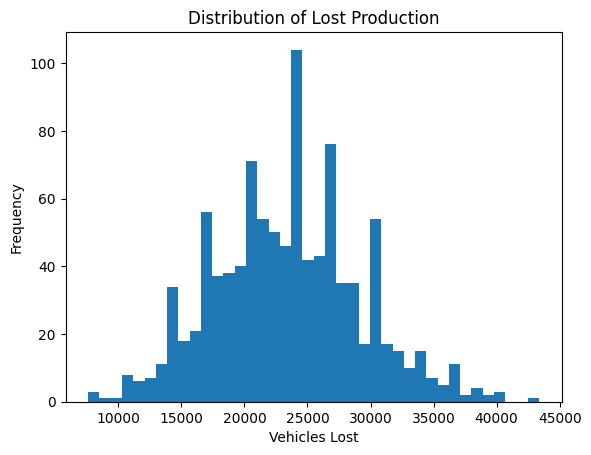

In [6]:
plt.hist(df["Lost Production"], bins=40)
plt.title("Distribution of Lost Production")
plt.xlabel("Vehicles Lost")
plt.ylabel("Frequency")
plt.show()

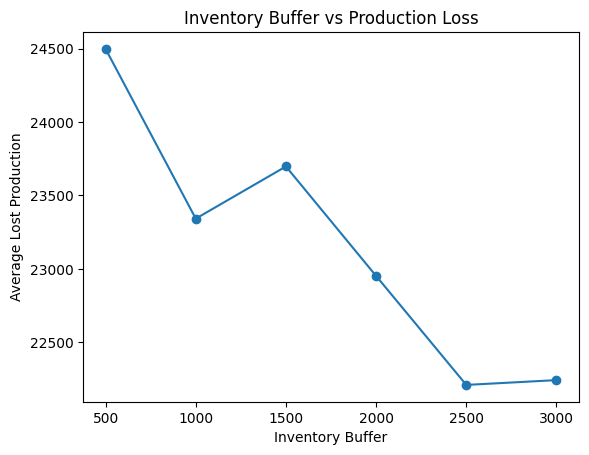

In [7]:
buffers = [500, 1000, 1500, 2000, 2500, 3000]

avg_loss = []

for buffer in buffers:

    global initial_inventory
    initial_inventory = buffer

    losses = []

    for i in range(200):
        lost, _, _ = run_simulation()
        losses.append(lost)

    avg_loss.append(np.mean(losses))

plt.plot(buffers, avg_loss, marker='o')
plt.xlabel("Inventory Buffer")
plt.ylabel("Average Lost Production")
plt.title("Inventory Buffer vs Production Loss")
plt.show()

In [8]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

In [9]:
apollo_takt = 75
discovery_takt = 78

apollo_prod_minutes = 450
discovery_prod_minutes = 444

apollo_rate = 60 / apollo_takt
discovery_rate = 60 / discovery_takt

apollo_daily = apollo_prod_minutes * apollo_rate
discovery_daily = discovery_prod_minutes * discovery_rate

plant_daily_output = apollo_daily + discovery_daily

operating_days = 240

In [10]:
buffer_days = 0.5   # half-day inventory
inventory = plant_daily_output * buffer_days

In [11]:
weather_events = [
    (0.03, 2),
    (0.05, 1),
    (0.01, 4)
]

In [12]:
def simulate_year():

    inventory = plant_daily_output * buffer_days
    lost_production = 0
    disruption_days = 0

    for day in range(operating_days):

        shutdown = 0

        for prob, duration in weather_events:
            if random.random() < prob:
                shutdown = duration
                break

        if shutdown > 0:
            disruption_days += shutdown

        deliveries = plant_daily_output if shutdown == 0 else 0

        inventory += deliveries

        if inventory >= plant_daily_output:
            inventory -= plant_daily_output
        else:
            lost_production += plant_daily_output - inventory
            inventory = 0

    return lost_production

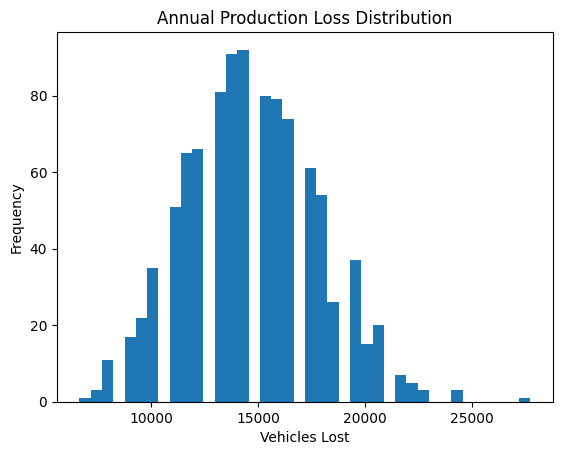

In [13]:
runs = 1000

results = []

for i in range(runs):
    results.append(simulate_year())

plt.hist(results, bins=40)
plt.title("Annual Production Loss Distribution")
plt.xlabel("Vehicles Lost")
plt.ylabel("Frequency")
plt.show()

In [14]:
apollo_takt = 75
discovery_takt = 78

apollo_minutes = 450
discovery_minutes = 444

apollo_rate = 60 / apollo_takt
discovery_rate = 60 / discovery_takt

apollo_daily = apollo_minutes * apollo_rate
discovery_daily = discovery_minutes * discovery_rate

total_daily = apollo_daily + discovery_daily
annual_output = total_daily * 240

print("Apollo vehicles/day:", round(apollo_daily))
print("Discovery vehicles/day:", round(discovery_daily))
print("Total vehicles/day:", round(total_daily))
print("Annual production:", round(annual_output))

Apollo vehicles/day: 360
Discovery vehicles/day: 342
Total vehicles/day: 702
Annual production: 168369


In [15]:
apollo_shift_output = 360
discovery_shift_output = 341

shifts_per_day = 2

apollo_daily = apollo_shift_output * shifts_per_day
discovery_daily = discovery_shift_output * shifts_per_day

plant_daily_output = apollo_daily + discovery_daily

operating_days = 240
annual_output = plant_daily_output * operating_days

print("Apollo vehicles/day:", apollo_daily)
print("Discovery vehicles/day:", discovery_daily)
print("Plant vehicles/day:", plant_daily_output)
print("Annual output:", annual_output)

Apollo vehicles/day: 720
Discovery vehicles/day: 682
Plant vehicles/day: 1402
Annual output: 336480


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
# Takt times (seconds)
apollo_takt = 75
discovery_takt = 78

# Convert to vehicles per minute
apollo_rate = 60 / apollo_takt
discovery_rate = 60 / discovery_takt

# Shift windows (minutes from midnight)
apollo_start = 7*60 + 8
discovery_start = 7*60 + 14
shift_end = 15*60 + 45

# Break schedule (relative to shift start)
breaks = [
    (120,130),   # 10 minute break
    (240,285),   # lunch
    (360,372)    # final break
]

# Inventory
inventory = 2000

In [18]:
def on_break(current_minute, shift_start):

    shift_min = current_minute - shift_start

    for b_start, b_end in breaks:
        if b_start <= shift_min < b_end:
            return True

    return False

In [19]:
timeline = []
apollo_output = 0
discovery_output = 0

for minute in range(1440):

    apollo_running = False
    discovery_running = False

    # Apollo shift
    if apollo_start <= minute < shift_end:
        if not on_break(minute, apollo_start):
            apollo_running = True

    # Discovery shift
    if discovery_start <= minute < shift_end:
        if not on_break(minute, discovery_start):
            discovery_running = True

    # Production
    apollo_prod = apollo_rate if apollo_running else 0
    discovery_prod = discovery_rate if discovery_running else 0

    apollo_output += apollo_prod
    discovery_output += discovery_prod

    timeline.append([
        minute,
        apollo_prod,
        discovery_prod,
        inventory
    ])

In [20]:
df = pd.DataFrame(
    timeline,
    columns=["Minute","Apollo Production","Discovery Production","Inventory"]
)

print("Apollo vehicles:", int(apollo_output))
print("Discovery vehicles:", int(discovery_output))
print("Total vehicles:", int(apollo_output + discovery_output))

Apollo vehicles: 360
Discovery vehicles: 341
Total vehicles: 701


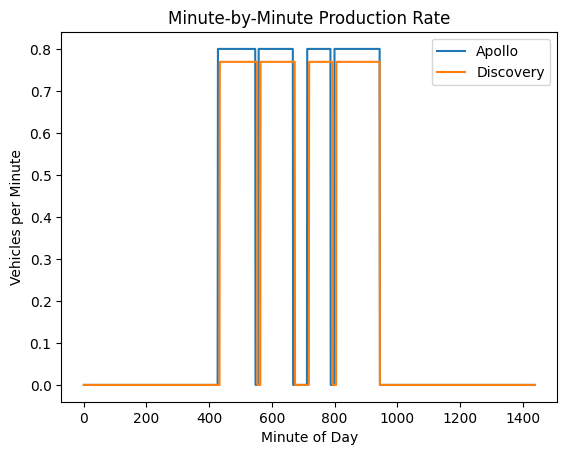

In [21]:
plt.plot(df["Minute"], df["Apollo Production"], label="Apollo")
plt.plot(df["Minute"], df["Discovery Production"], label="Discovery")

plt.title("Minute-by-Minute Production Rate")
plt.xlabel("Minute of Day")
plt.ylabel("Vehicles per Minute")
plt.legend()

plt.show()

In [22]:
consumption = apollo_prod + discovery_prod
inventory -= consumption

if inventory < 0:
    inventory = 0

In [23]:
storm_start = 600
storm_duration = 180

In [24]:
if storm_start <= minute <= storm_start + storm_duration:
    deliveries = 0
else:
    deliveries = 50

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
# Takt times (seconds)
apollo_takt = 75
discovery_takt = 78

# Vehicles per minute
apollo_rate = 60 / apollo_takt
discovery_rate = 60 / discovery_takt

# Shift start times (minutes after midnight)
apollo_start = 7*60 + 8
discovery_start = 7*60 + 14

# Shift end
shift_end = 15*60 + 45

# Break schedule (minutes after shift start)
breaks = [
    (120,130),   # 10 min break
    (240,285),   # lunch
    (360,372)    # final break
]

# Starting inventory (parts)
inventory = 2000

In [27]:
def on_break(current_minute, shift_start):

    shift_min = current_minute - shift_start

    for b_start, b_end in breaks:
        if b_start <= shift_min < b_end:
            return True

    return False

In [28]:
timeline = []

apollo_output = 0
discovery_output = 0

inventory_levels = []

for minute in range(1440):

    apollo_running = False
    discovery_running = False

    # Apollo running check
    if apollo_start <= minute < shift_end:
        if not on_break(minute, apollo_start):
            apollo_running = True

    # Discovery running check
    if discovery_start <= minute < shift_end:
        if not on_break(minute, discovery_start):
            discovery_running = True

    # Production this minute
    apollo_prod = apollo_rate if apollo_running else 0
    discovery_prod = discovery_rate if discovery_running else 0

    total_prod = apollo_prod + discovery_prod

    apollo_output += apollo_prod
    discovery_output += discovery_prod

    inventory -= total_prod
    if inventory < 0:
        inventory = 0

    inventory_levels.append(inventory)

    timeline.append([
        minute,
        apollo_prod,
        discovery_prod,
        inventory
    ])

In [29]:
df = pd.DataFrame(
    timeline,
    columns=["Minute","Apollo","Discovery","Inventory"]
)

print("Apollo vehicles:", int(apollo_output))
print("Discovery vehicles:", int(discovery_output))
print("Total vehicles:", int(apollo_output + discovery_output))

Apollo vehicles: 360
Discovery vehicles: 341
Total vehicles: 701


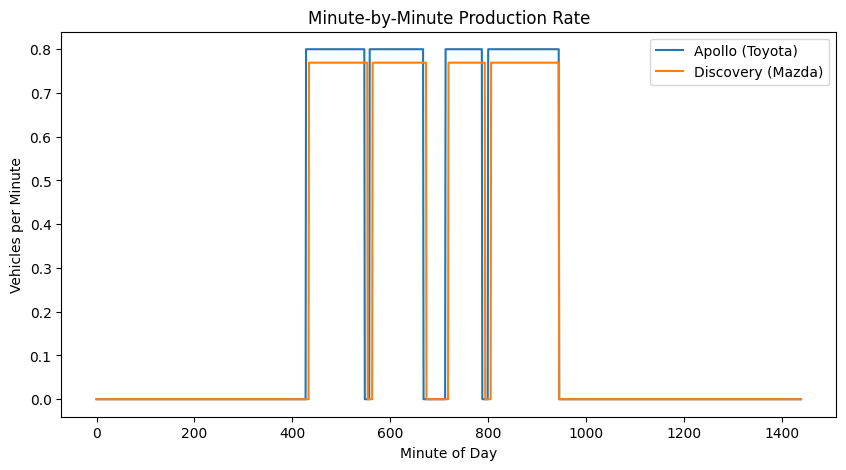

In [30]:
plt.figure(figsize=(10,5))

plt.plot(df["Minute"], df["Apollo"], label="Apollo (Toyota)")
plt.plot(df["Minute"], df["Discovery"], label="Discovery (Mazda)")

plt.title("Minute-by-Minute Production Rate")
plt.xlabel("Minute of Day")
plt.ylabel("Vehicles per Minute")

plt.legend()
plt.show()

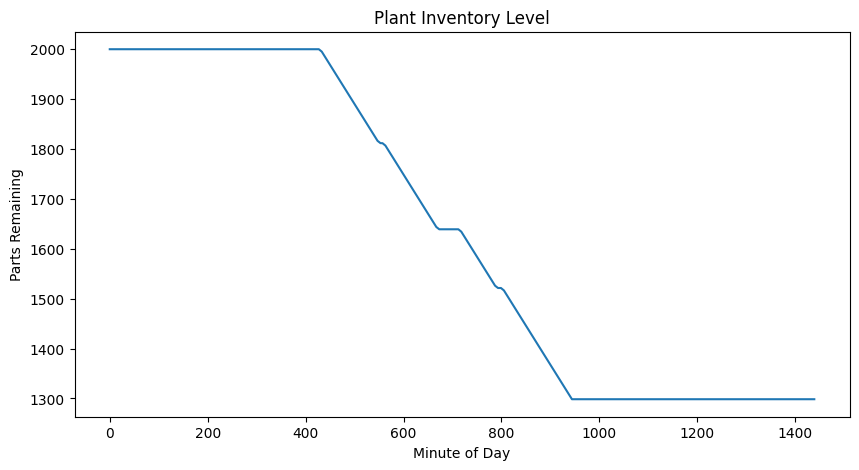

In [31]:
plt.figure(figsize=(10,5))

plt.plot(df["Minute"], inventory_levels)

plt.title("Plant Inventory Level")
plt.xlabel("Minute of Day")
plt.ylabel("Parts Remaining")

plt.show()

In [32]:
storm_start = 600
storm_duration = 180

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [34]:
# Takt times
apollo_takt = 75
discovery_takt = 78

# Vehicles per minute
apollo_rate = 60 / apollo_takt
discovery_rate = 60 / discovery_takt

# Shift start times
apollo_start = 7*60 + 8
discovery_start = 7*60 + 14

# Shift end
shift_end = 15*60 + 45

# Break schedule
breaks = [
    (120,130),   # 10 min
    (240,285),   # lunch
    (360,372)    # 12 min
]

# Starting inventory
inventory = 2000

In [35]:
def on_break(current_minute, shift_start):

    shift_min = current_minute - shift_start

    for b_start, b_end in breaks:
        if b_start <= shift_min < b_end:
            return True

    return False

In [36]:
timeline = []

apollo_output = 0
discovery_output = 0

inventory_levels = []

for minute in range(1440):

    apollo_running = False
    discovery_running = False

    if apollo_start <= minute < shift_end:
        if not on_break(minute, apollo_start):
            apollo_running = True

    if discovery_start <= minute < shift_end:
        if not on_break(minute, discovery_start):
            discovery_running = True

    apollo_prod = apollo_rate if apollo_running else 0
    discovery_prod = discovery_rate if discovery_running else 0

    total_prod = apollo_prod + discovery_prod

    apollo_output += apollo_prod
    discovery_output += discovery_prod

    inventory -= total_prod

    if inventory < 0:
        inventory = 0

    inventory_levels.append(inventory)

    timeline.append([minute, apollo_prod, discovery_prod])

In [37]:
print("Apollo vehicles:", int(apollo_output))
print("Discovery vehicles:", int(discovery_output))
print("Total vehicles:", int(apollo_output + discovery_output))

Apollo vehicles: 360
Discovery vehicles: 341
Total vehicles: 701


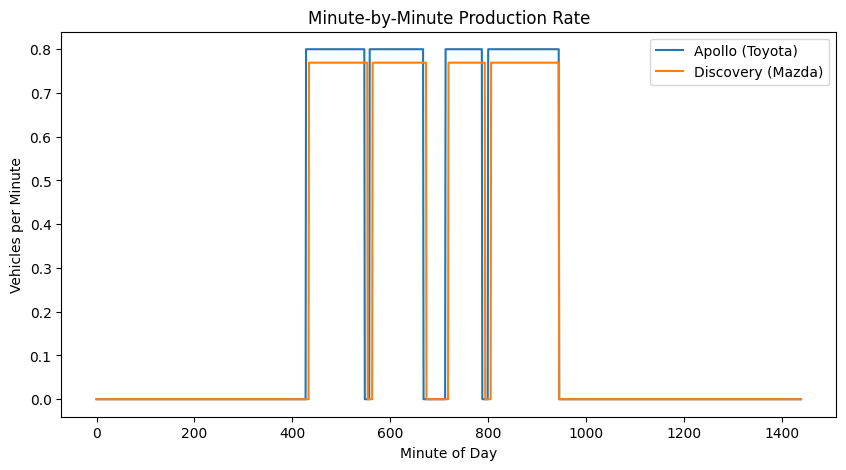

In [38]:
df = pd.DataFrame(timeline, columns=["Minute","Apollo","Discovery"])

plt.figure(figsize=(10,5))

plt.plot(df["Minute"], df["Apollo"], label="Apollo (Toyota)")
plt.plot(df["Minute"], df["Discovery"], label="Discovery (Mazda)")

plt.title("Minute-by-Minute Production Rate")
plt.xlabel("Minute of Day")
plt.ylabel("Vehicles per Minute")

plt.legend()
plt.show()

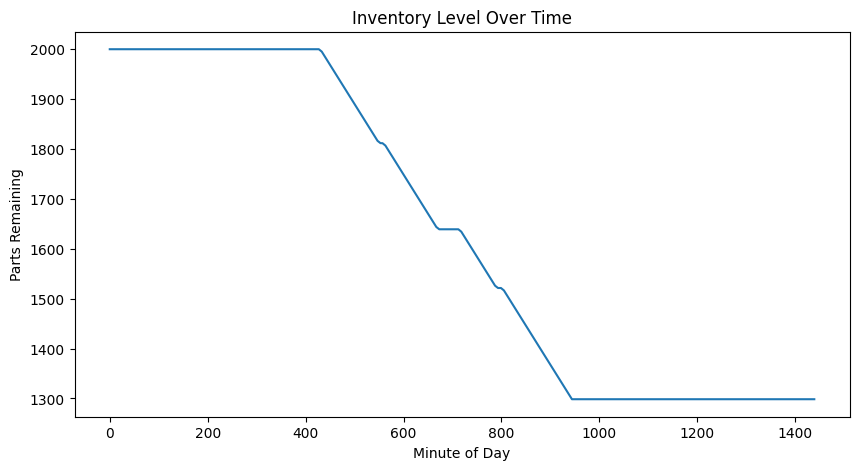

In [39]:
plt.figure(figsize=(10,5))

plt.plot(inventory_levels)

plt.title("Inventory Level Over Time")
plt.xlabel("Minute of Day")
plt.ylabel("Parts Remaining")

plt.show()

In [40]:
storm_start = 600
storm_duration = 180

In [41]:
if storm_start <= minute <= storm_start + storm_duration:
    deliveries = 0
else:
    deliveries = 50

inventory += deliveries

Vehicles produced: 701


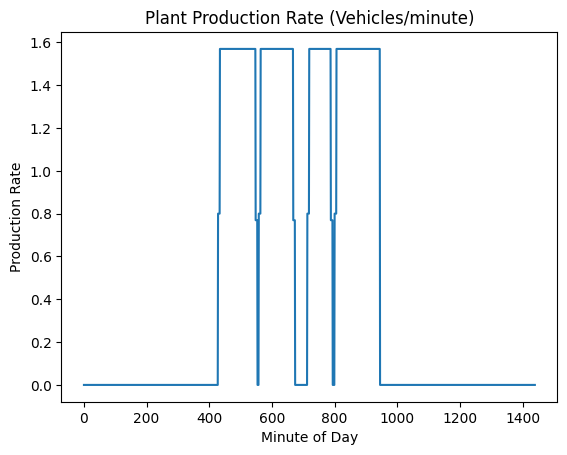

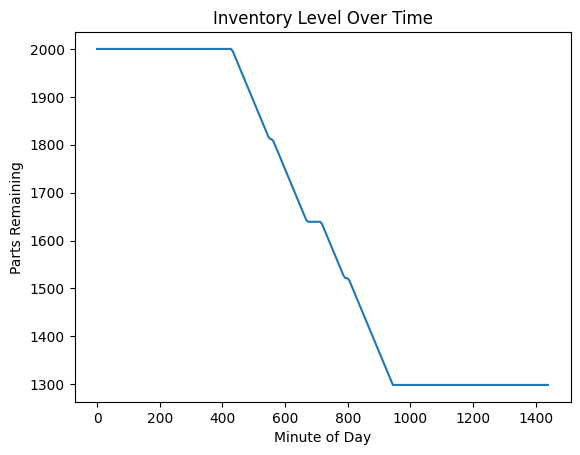

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------
# Plant Parameters
# -------------------

apollo_takt = 75
discovery_takt = 78

apollo_rate = 60/apollo_takt
discovery_rate = 60/discovery_takt

apollo_start = 7*60 + 8
discovery_start = 7*60 + 14
shift_end = 15*60 + 45

breaks = [(120,130),(240,285),(360,372)]

inventory = 2000

# -------------------
# Break Check
# -------------------

def on_break(minute, shift_start):
    shift_min = minute - shift_start
    for b in breaks:
        if b[0] <= shift_min < b[1]:
            return True
    return False

# -------------------
# Simulation
# -------------------

minutes = []
production = []
inventory_levels = []

vehicles = 0

for minute in range(1440):

    apollo_running = False
    discovery_running = False

    if apollo_start <= minute < shift_end:
        if not on_break(minute, apollo_start):
            apollo_running = True

    if discovery_start <= minute < shift_end:
        if not on_break(minute, discovery_start):
            discovery_running = True

    apollo_prod = apollo_rate if apollo_running else 0
    discovery_prod = discovery_rate if discovery_running else 0

    total = apollo_prod + discovery_prod

    vehicles += total
    inventory -= total

    if inventory < 0:
        inventory = 0

    minutes.append(minute)
    production.append(total)
    inventory_levels.append(inventory)

# -------------------
# Results
# -------------------

print("Vehicles produced:", int(vehicles))

# -------------------
# Graphs
# -------------------

plt.figure()
plt.plot(minutes, production)
plt.title("Plant Production Rate (Vehicles/minute)")
plt.xlabel("Minute of Day")
plt.ylabel("Production Rate")
plt.show()

plt.figure()
plt.plot(minutes, inventory_levels)
plt.title("Inventory Level Over Time")
plt.xlabel("Minute of Day")
plt.ylabel("Parts Remaining")
plt.show()

Vehicles produced: 701


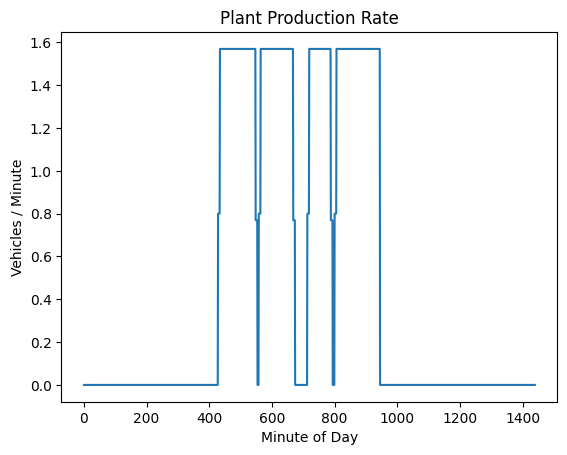

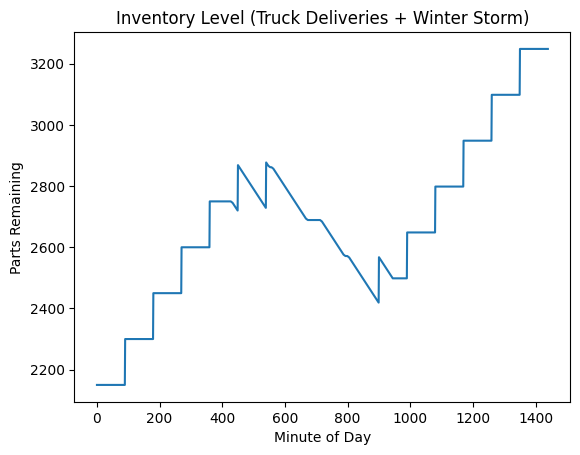

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Plant Parameters
# -----------------------------

apollo_takt = 75
discovery_takt = 78

apollo_rate = 60/apollo_takt
discovery_rate = 60/discovery_takt

apollo_start = 7*60 + 8
discovery_start = 7*60 + 14
shift_end = 15*60 + 45

breaks = [(120,130),(240,285),(360,372)]

# -----------------------------
# Inventory + Truck Parameters
# -----------------------------

inventory = 2000

truck_interval = 90     # minutes between trucks
truck_parts = 150        # parts per truck

# -----------------------------
# Winter Storm
# -----------------------------

storm_start = 10*60 + 30      # 10:30 AM
storm_duration = 180         # 3 hours

storm_end = storm_start + storm_duration

# -----------------------------
# Break Check
# -----------------------------

def on_break(minute, shift_start):
    shift_min = minute - shift_start
    for b in breaks:
        if b[0] <= shift_min < b[1]:
            return True
    return False

# -----------------------------
# Simulation
# -----------------------------

minutes = []
production = []
inventory_levels = []
truck_arrivals = []

vehicles = 0

for minute in range(1440):

    apollo_running = False
    discovery_running = False

    # Shift checks
    if apollo_start <= minute < shift_end:
        if not on_break(minute, apollo_start):
            apollo_running = True

    if discovery_start <= minute < shift_end:
        if not on_break(minute, discovery_start):
            discovery_running = True

    # Production
    apollo_prod = apollo_rate if apollo_running else 0
    discovery_prod = discovery_rate if discovery_running else 0

    total_prod = apollo_prod + discovery_prod

    vehicles += total_prod
    inventory -= total_prod

    # -----------------------------
    # Truck Deliveries
    # -----------------------------

    truck = False

    if minute % truck_interval == 0:

        # Storm stops trucks
        if not (storm_start <= minute <= storm_end):

            inventory += truck_parts
            truck = True

    # Prevent negative inventory
    if inventory < 0:
        inventory = 0

    minutes.append(minute)
    production.append(total_prod)
    inventory_levels.append(inventory)
    truck_arrivals.append(truck)

# -----------------------------
# Results
# -----------------------------

print("Vehicles produced:", int(vehicles))

# -----------------------------
# Graph: Production
# -----------------------------

plt.figure()

plt.plot(minutes, production)

plt.title("Plant Production Rate")
plt.xlabel("Minute of Day")
plt.ylabel("Vehicles / Minute")

plt.show()

# -----------------------------
# Graph: Inventory
# -----------------------------

plt.figure()

plt.plot(minutes, inventory_levels)

plt.title("Inventory Level (Truck Deliveries + Winter Storm)")
plt.xlabel("Minute of Day")
plt.ylabel("Parts Remaining")

plt.show()

Vehicles produced: 701


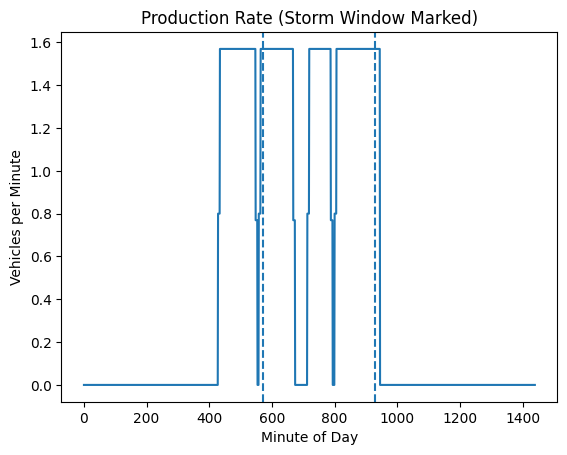

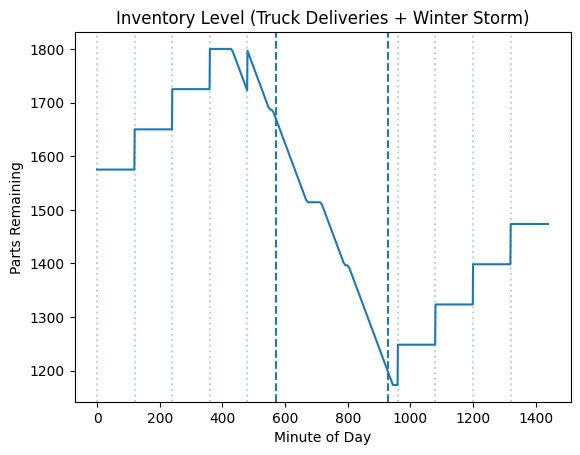

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Plant Parameters
# -----------------------------

apollo_takt = 75
discovery_takt = 78

apollo_rate = 60/apollo_takt
discovery_rate = 60/discovery_takt

apollo_start = 7*60 + 8
discovery_start = 7*60 + 14
shift_end = 15*60 + 45

breaks = [(120,130),(240,285),(360,372)]

# -----------------------------
# Inventory + Trucks
# -----------------------------

inventory = 1500

truck_interval = 120
truck_parts = 75

# -----------------------------
# Winter Storm
# -----------------------------

storm_start = 9*60 + 30
storm_duration = 360
storm_end = storm_start + storm_duration

# -----------------------------
# Break Check
# -----------------------------

def on_break(minute, shift_start):

    shift_min = minute - shift_start

    for b in breaks:
        if b[0] <= shift_min < b[1]:
            return True

    return False

# -----------------------------
# Simulation
# -----------------------------

minutes = []
production = []
inventory_levels = []
truck_times = []

vehicles = 0

for minute in range(1440):

    apollo_running = False
    discovery_running = False

    if apollo_start <= minute < shift_end:
        if not on_break(minute, apollo_start):
            apollo_running = True

    if discovery_start <= minute < shift_end:
        if not on_break(minute, discovery_start):
            discovery_running = True

    apollo_prod = apollo_rate if apollo_running else 0
    discovery_prod = discovery_rate if discovery_running else 0

    total_prod = apollo_prod + discovery_prod

    vehicles += total_prod
    inventory -= total_prod

    # Truck arrivals
    if minute % truck_interval == 0:

        if not (storm_start <= minute <= storm_end):

            inventory += truck_parts
            truck_times.append(minute)

    if inventory < 0:
        inventory = 0

    minutes.append(minute)
    production.append(total_prod)
    inventory_levels.append(inventory)

print("Vehicles produced:", int(vehicles))

# -----------------------------
# Production Graph
# -----------------------------

plt.figure()

plt.plot(minutes, production)

plt.axvline(storm_start, linestyle='--')
plt.axvline(storm_end, linestyle='--')

plt.title("Production Rate (Storm Window Marked)")
plt.xlabel("Minute of Day")
plt.ylabel("Vehicles per Minute")

plt.show()

# -----------------------------
# Inventory Graph
# -----------------------------

plt.figure()

plt.plot(minutes, inventory_levels)

for t in truck_times:
    plt.axvline(t, linestyle=':', alpha=0.3)

plt.axvline(storm_start, linestyle='--')
plt.axvline(storm_end, linestyle='--')

plt.title("Inventory Level (Truck Deliveries + Winter Storm)")
plt.xlabel("Minute of Day")
plt.ylabel("Parts Remaining")

plt.show()

Average vehicles lost: 18.1
Worst case: 169.5
Shutdown probability: 0.13


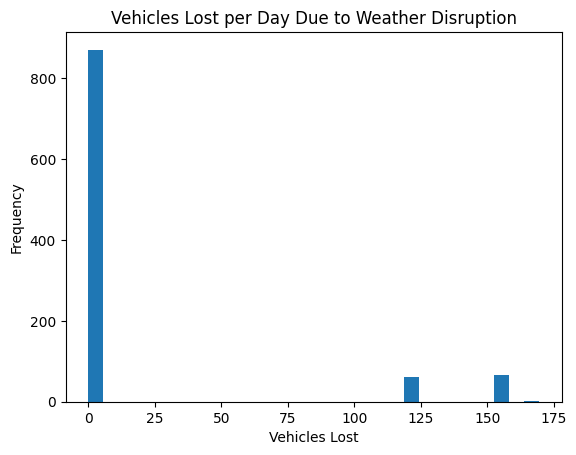

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import random

# ---------------------------
# Plant production parameters
# ---------------------------

apollo_takt = 75
discovery_takt = 78

apollo_rate = 60 / apollo_takt
discovery_rate = 60 / discovery_takt

apollo_start = 7*60 + 8
discovery_start = 7*60 + 14
shift_end = 15*60 + 45

breaks = [(120,130), (240,285), (360,372)]

expected_output = 701   # one shift production

truck_interval = 120    # trucks every 2 hours
truck_parts = 200

# ---------------------------
# Break check
# ---------------------------

def on_break(minute, shift_start):

    shift_min = minute - shift_start

    for b in breaks:
        if b[0] <= shift_min < b[1]:
            return True

    return False

# ---------------------------
# One-day simulation
# ---------------------------

def simulate_day():

    inventory = 180
    vehicles = 0

    # 25% chance of storm
    storm_today = random.random() < 0.25

    if storm_today:
        storm_start = random.randint(480,720)
        storm_duration = random.choice([120,180,240])
        storm_end = storm_start + storm_duration
    else:
        storm_start = -1
        storm_end = -1

    for minute in range(1440):

        apollo_running = False
        discovery_running = False

        if apollo_start <= minute < shift_end:
            apollo_running = True

        if discovery_start <= minute < shift_end:
            discovery_running = True

        apollo_prod = apollo_rate if apollo_running else 0
        discovery_prod = discovery_rate if discovery_running else 0

        total_prod = apollo_prod + discovery_prod

        # production limited by inventory
        if inventory >= total_prod:
            vehicles += total_prod
            inventory -= total_prod
        else:
            vehicles += inventory
            inventory = 0

        # truck deliveries every 2 hours
        if minute > 0 and minute % truck_interval == 0 and apollo_start <= minute < shift_end:

            # trucks blocked during storm
            if not (storm_start <= minute <= storm_end):
                inventory += truck_parts

    return vehicles

# ---------------------------
# Monte Carlo simulation
# ---------------------------

runs = 1000

results = []

for i in range(runs):
    results.append(simulate_day())

losses = [max(0, expected_output - r) for r in results]

print("Average vehicles lost:", round(np.mean(losses),1))
print("Worst case:", round(max(losses),1))
print("Shutdown probability:", round(sum(l>0 for l in losses)/runs,2))

# ---------------------------
# Histogram
# ---------------------------

plt.hist(losses, bins=30)

plt.title("Vehicles Lost per Day Due to Weather Disruption")
plt.xlabel("Vehicles Lost")
plt.ylabel("Frequency")

plt.show()

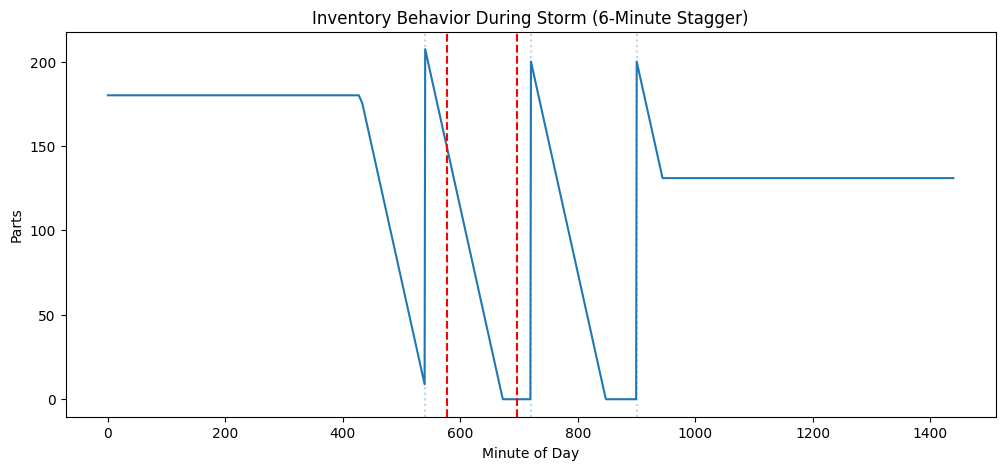

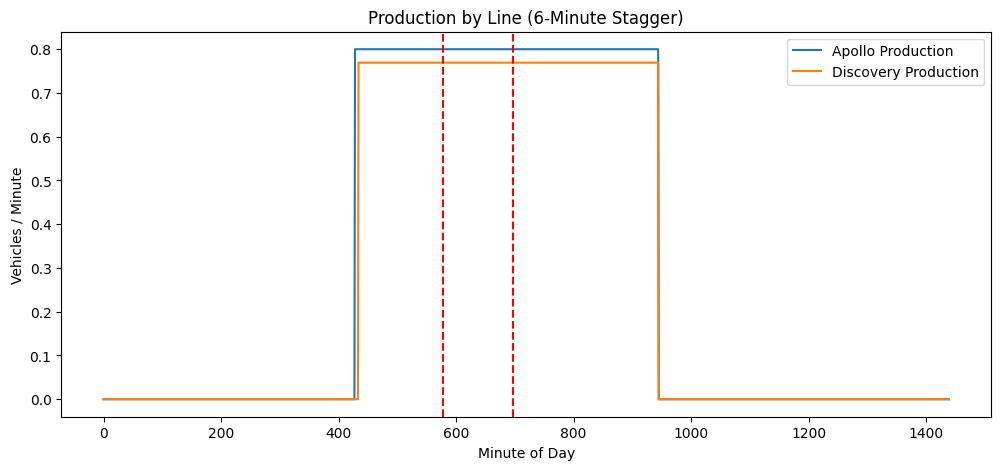

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import random

# -----------------------------
# Plant parameters
# -----------------------------

apollo_takt = 75
discovery_takt = 78

apollo_rate = 60 / apollo_takt
discovery_rate = 60 / discovery_takt

apollo_start = 7*60 + 8
discovery_start = 7*60 + 14
shift_end = 15*60 + 45

truck_interval = 180
truck_parts = 200

inventory = 180

# -----------------------------
# Storm setup
# -----------------------------

storm_start = random.randint(480,720)
storm_duration = random.choice([120,180,240])
storm_end = storm_start + storm_duration

# -----------------------------
# Simulation
# -----------------------------

minutes = []
inventory_levels = []
apollo_prod_series = []
discovery_prod_series = []
truck_times = []

for minute in range(1440):

    apollo_running = False
    discovery_running = False

    if apollo_start <= minute < shift_end:
        apollo_running = True

    if discovery_start <= minute < shift_end:
        discovery_running = True

    apollo_prod = apollo_rate if apollo_running else 0
    discovery_prod = discovery_rate if discovery_running else 0

    total_prod = apollo_prod + discovery_prod

    if inventory >= total_prod:
        inventory -= total_prod
    else:
        total_prod = inventory
        inventory = 0

    # truck arrivals
    if minute > 0 and minute % truck_interval == 0 and apollo_start <= minute < shift_end:

        if not (storm_start <= minute <= storm_end):
            inventory += truck_parts
            truck_times.append(minute)

    minutes.append(minute)
    inventory_levels.append(inventory)
    apollo_prod_series.append(apollo_prod)
    discovery_prod_series.append(discovery_prod)

# -----------------------------
# Inventory graph
# -----------------------------

plt.figure(figsize=(12,5))

plt.plot(minutes, inventory_levels, label="Inventory")

for t in truck_times:
    plt.axvline(t, linestyle=":", alpha=0.3)

plt.axvline(storm_start, linestyle="--", color="red")
plt.axvline(storm_end, linestyle="--", color="red")

plt.title("Inventory Behavior During Storm (6-Minute Stagger)")
plt.xlabel("Minute of Day")
plt.ylabel("Parts")

plt.show()

# -----------------------------
# Production graph
# -----------------------------

plt.figure(figsize=(12,5))

plt.plot(minutes, apollo_prod_series, label="Apollo Production")
plt.plot(minutes, discovery_prod_series, label="Discovery Production")

plt.axvline(storm_start, linestyle="--", color="red")
plt.axvline(storm_end, linestyle="--", color="red")

plt.title("Production by Line (6-Minute Stagger)")
plt.xlabel("Minute of Day")
plt.ylabel("Vehicles / Minute")

plt.legend()

plt.show()

Average vehicles lost per day: 43.7
Worst single-day loss: 332.0
Total annual vehicles lost: 10484.9


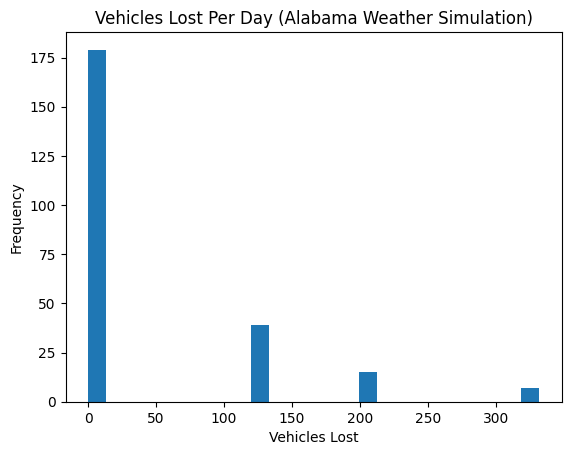

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import random

# -----------------------------
# Plant parameters
# -----------------------------

apollo_takt = 75
discovery_takt = 78

apollo_rate = 60 / apollo_takt
discovery_rate = 60 / discovery_takt

apollo_start = 7*60 + 8
discovery_start = 7*60 + 14
shift_end = 15*60 + 45

truck_interval = 180
truck_parts = 200

starting_inventory = 300

expected_daily_output = 701

# -----------------------------
# Storm severity model
# -----------------------------

def generate_storm():

    if random.random() < 0.30:   # 30% chance of weather disruption

        storm_type = random.choice([
            ("Thunderstorm",60),
            ("Severe Storm",120),
            ("Ice Storm",240),
            ("Tornado Outbreak",300)
        ])

        return storm_type

    return ("None",0)

# -----------------------------
# One-day simulation
# -----------------------------

def simulate_day():

    inventory = starting_inventory
    vehicles = 0

    storm_type, storm_duration = generate_storm()

    if storm_type != "None":
        storm_start = random.randint(480,720)
        storm_end = storm_start + storm_duration
    else:
        storm_start = -1
        storm_end = -1

    for minute in range(1440):

        apollo_running = False
        discovery_running = False

        if apollo_start <= minute < shift_end:
            apollo_running = True

        if discovery_start <= minute < shift_end:
            discovery_running = True

        apollo_prod = apollo_rate if apollo_running else 0
        discovery_prod = discovery_rate if discovery_running else 0

        total_prod = apollo_prod + discovery_prod

        if inventory >= total_prod:
            vehicles += total_prod
            inventory -= total_prod
        else:
            vehicles += inventory
            inventory = 0

        # truck deliveries
        if minute > 0 and minute % truck_interval == 0 and apollo_start <= minute < shift_end:

            if not (storm_start <= minute <= storm_end):
                inventory += truck_parts

    return vehicles

# -----------------------------
# Year simulation
# -----------------------------

days = 240

year_losses = []

for d in range(days):

    produced = simulate_day()

    loss = max(0, expected_daily_output - produced)

    year_losses.append(loss)

# -----------------------------
# Results
# -----------------------------

print("Average vehicles lost per day:", round(np.mean(year_losses),1))
print("Worst single-day loss:", round(max(year_losses),1))
print("Total annual vehicles lost:", round(sum(year_losses),1))

# -----------------------------
# Histogram
# -----------------------------

plt.hist(year_losses,bins=25)

plt.title("Vehicles Lost Per Day (Alabama Weather Simulation)")
plt.xlabel("Vehicles Lost")
plt.ylabel("Frequency")

plt.show()

Average vehicles lost per day: 63.9
Worst single-day loss: 452.0
Total annual vehicles lost: 15338.0


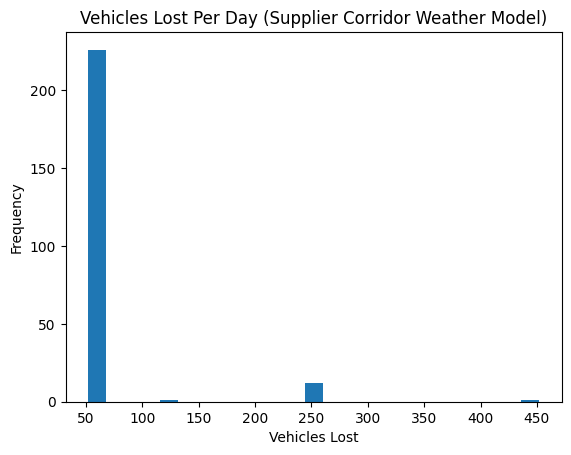

In [101]:
import numpy as np
import matplotlib.pyplot as plt
import random

# -----------------------------
# Plant parameters
# -----------------------------

apollo_takt = 75
discovery_takt = 78

apollo_rate = 60 / apollo_takt
discovery_rate = 60 / discovery_takt

apollo_start = 7*60 + 8
discovery_start = 7*60 + 14
shift_end = 15*60 + 45

truck_interval = 180
truck_parts = 200

starting_inventory = 180

expected_daily_output = 701

# -----------------------------
# Supplier corridors
# -----------------------------

corridors = ["North","South","East","West"]

# each truck assigned to corridor
def truck_corridor():
    return random.choice(corridors)

# -----------------------------
# Storm generator
# -----------------------------

def generate_storm():

    if random.random() < 0.30:

        storm_type = random.choice([
            ("Thunderstorm",60),
            ("Severe Storm",120),
            ("Ice Storm",240),
            ("Tornado Outbreak",300)
        ])

        corridor_hit = random.choice(corridors)

        return storm_type[0], storm_type[1], corridor_hit

    return "None",0,None

# -----------------------------
# One-day simulation
# -----------------------------

def simulate_day():

    inventory = starting_inventory
    vehicles = 0

    storm_type, storm_duration, corridor_hit = generate_storm()

    if storm_type != "None":
        storm_start = random.randint(480,720)
        storm_end = storm_start + storm_duration
    else:
        storm_start = -1
        storm_end = -1

    for minute in range(1440):

        apollo_running = False
        discovery_running = False

        if apollo_start <= minute < shift_end:
            apollo_running = True

        if discovery_start <= minute < shift_end:
            discovery_running = True

        apollo_prod = apollo_rate if apollo_running else 0
        discovery_prod = discovery_rate if discovery_running else 0

        total_prod = apollo_prod + discovery_prod

        if inventory >= total_prod:
            vehicles += total_prod
            inventory -= total_prod
        else:
            vehicles += inventory
            inventory = 0

        # truck deliveries
        if minute > 0 and minute % truck_interval == 0 and apollo_start <= minute < shift_end:

            corridor = truck_corridor()

            if not (storm_start <= minute <= storm_end and corridor == corridor_hit):
                inventory += truck_parts

    return vehicles

# -----------------------------
# Year simulation
# -----------------------------

days = 240
year_losses = []

for d in range(days):

    produced = simulate_day()

    loss = max(0, expected_daily_output - produced)

    year_losses.append(loss)

print("Average vehicles lost per day:", round(np.mean(year_losses),1))
print("Worst single-day loss:", round(max(year_losses),1))
print("Total annual vehicles lost:", round(sum(year_losses),1))

plt.hist(year_losses,bins=25)

plt.title("Vehicles Lost Per Day (Supplier Corridor Weather Model)")
plt.xlabel("Vehicles Lost")
plt.ylabel("Frequency")

plt.show()

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import random

# =============================
# Core plant parameters
# =============================

apollo_takt = 75
discovery_takt = 78

apollo_rate = 60 / apollo_takt
discovery_rate = 60 / discovery_takt

shift_end = 15 * 60 + 45

truck_interval = 180
truck_parts = 200

starting_inventory = 180
expected_daily_output = 701

corridors = ["North", "South", "East", "West"]

# =============================
# Season calendar for 240 days
# 60 winter, 60 spring, 60 summer, 60 fall
# =============================

season_by_day = (
    ["Winter"] * 60 +
    ["Spring"] * 60 +
    ["Summer"] * 60 +
    ["Fall"] * 60
)

# -----------------------------
# Weather system generator
# -----------------------------

storm_active = False
storm_days_remaining = 0
storm_corridor = None
storm_type = None


def generate_storm(season):

    global storm_active, storm_days_remaining, storm_corridor, storm_type

    if storm_active:

        storm_days_remaining -= 1

        if storm_days_remaining <= 0:
            storm_active = False

        return storm_type

    r = random.random()

    if season == "Spring":

        if r < 0.18:
            storm_active = True
            storm_days_remaining = random.randint(2,4)
            storm_corridor = random.choice(corridors)
            storm_type = ("Tornado Outbreak", random.choice([240,300,360]), storm_corridor)
            return storm_type

    elif season == "Winter":

        if r < 0.12:
            storm_active = True
            storm_days_remaining = random.randint(2,3)
            storm_corridor = random.choice(corridors)
            storm_type = ("Ice Storm", random.choice([240,300]), storm_corridor)
            return storm_type

    elif season == "Summer":

        if r < 0.20:
            return ("Thunderstorm",60,random.choice(corridors))

    elif season == "Fall":

        if r < 0.10:
            return ("Thunderstorm",60,random.choice(corridors))

    return ("None",0,None)

# =============================
# One-day simulation
# =============================

def simulate_day(apollo_start, discovery_start, season):
    inventory = {
    "electronics": starting_inventory,
    "seats": starting_inventory,
    "engines": starting_inventory,
    "panels": starting_inventory,
    "paint": starting_inventory
}
    vehicles = 0.0

    storm_type, storm_duration, corridor_hit = generate_storm(season)

    if storm_type != "None":
        storm_start = random.randint(480, 720)   # sometime between 8:00 and 12:00
        storm_end = storm_start + storm_duration
    else:
        storm_start = -1
        storm_end = -1

    for minute in range(1440):
        apollo_running = apollo_start <= minute < shift_end
        discovery_running = discovery_start <= minute < shift_end

        apollo_prod = apollo_rate if apollo_running else 0.0
        discovery_prod = discovery_rate if discovery_running else 0.0

        total_prod = apollo_prod + discovery_prod

        # production limited by the scarcest component
        available_parts = min(inventory.values())

        if available_parts >= total_prod:

            vehicles += total_prod

            for part in inventory:
              inventory[part] -= total_prod

        else:
            vehicles += available_parts

            for part in inventory:
              inventory[part] = max(0, inventory[part] = available_parts)


        # Truck arrivals only during production window, not at minute 0
        if minute > 0 and minute % truck_interval == 0 and apollo_start <= minute < shift_end:

            component = random.choice (list(inventory.keys()))
            corridor = random.choice(corridors)

            blocked = (
                storm_start <= minute <= storm_end and
                corridor == corridor_hit
            )

            if not blocked:
                inventory[component] += truck_parts

    daily_loss = max(0.0, expected_daily_output - vehicles)

    return {
        "season": season,
        "storm_type": storm_type,
        "vehicles_produced": vehicles,
        "vehicles_lost": daily_loss
    }

# =============================
# Year simulation
# =============================

def simulate_year(apollo_start, discovery_start):
    results = []

    for season in season_by_day:
        results.append(simulate_day(apollo_start, discovery_start, season))

    return results

# =============================
# Run both scenarios
# =============================

# Scenario A: real stagger
results_stagger = simulate_year(
    apollo_start=7 * 60 + 8,
    discovery_start=7 * 60 + 14
)

# Scenario B: no stagger
results_no_stagger = simulate_year(
    apollo_start=7 * 60 + 8,
    discovery_start=7 * 60 + 8
)

# =============================
# Summaries
# =============================

def summarize(results, label):
    losses = [r["vehicles_lost"] for r in results]

    print(f"\n--- {label} ---")
    print("Average vehicles lost per day:", round(np.mean(losses), 1))
    print("Worst single-day loss:", round(np.max(losses), 1))
    print("Total annual vehicles lost:", round(np.sum(losses), 1))
    print("Shutdown day probability:", round(sum(l > 0 for l in losses) / len(losses), 2))

def seasonal_summary(results):
    out = {}
    for season in ["Winter", "Spring", "Summer", "Fall"]:
        vals = [r["vehicles_lost"] for r in results if r["season"] == season]
        out[season] = np.mean(vals)
    return out

summarize(results_stagger, "Scenario A: 6-Minute Stagger")
summarize(results_no_stagger, "Scenario B: No Stagger")

seasonal_stagger = seasonal_summary(results_stagger)
seasonal_no_stagger = seasonal_summary(results_no_stagger)

# =============================
# Plots
# =============================

# Histogram comparison
plt.figure(figsize=(10, 5))
plt.hist([r["vehicles_lost"] for r in results_stagger], bins=25, alpha=0.7, label="6-Minute Stagger")
plt.hist([r["vehicles_lost"] for r in results_no_stagger], bins=25, alpha=0.7, label="No Stagger")
plt.title("Vehicles Lost Per Day: Stagger vs No Stagger")
plt.xlabel("Vehicles Lost")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Seasonal averages
seasons = ["Winter", "Spring", "Summer", "Fall"]
stagger_vals = [seasonal_stagger[s] for s in seasons]
no_stagger_vals = [seasonal_no_stagger[s] for s in seasons]

x = np.arange(len(seasons))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, stagger_vals, width, label="6-Minute Stagger")
plt.bar(x + width/2, no_stagger_vals, width, label="No Stagger")
plt.xticks(x, seasons)
plt.title("Average Vehicles Lost Per Day by Season")
plt.ylabel("Average Vehicles Lost")
plt.legend()
plt.show()

# Daily loss trace across the 240-day year
plt.figure(figsize=(12, 5))
plt.plot([r["vehicles_lost"] for r in results_stagger], label="6-Minute Stagger")
plt.plot([r["vehicles_lost"] for r in results_no_stagger], label="No Stagger", alpha=0.8)
plt.title("Daily Vehicles Lost Across Simulated Year")
plt.xlabel("Production Day")
plt.ylabel("Vehicles Lost")
plt.legend()
plt.show()

SyntaxError: expression cannot contain assignment, perhaps you meant "=="? (659814167.py, line 138)


Scenario A: 6-Minute Stagger
Average vehicles lost/day: 8.0
Worst day: 169.5
Annual vehicles lost: 1928.7

Scenario B: No Stagger
Average vehicles lost/day: 7.5
Worst day: 221.0
Annual vehicles lost: 1793.2


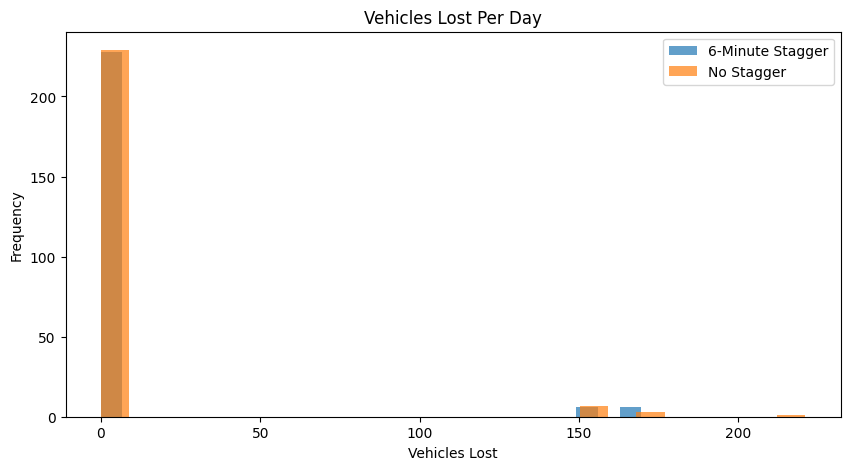

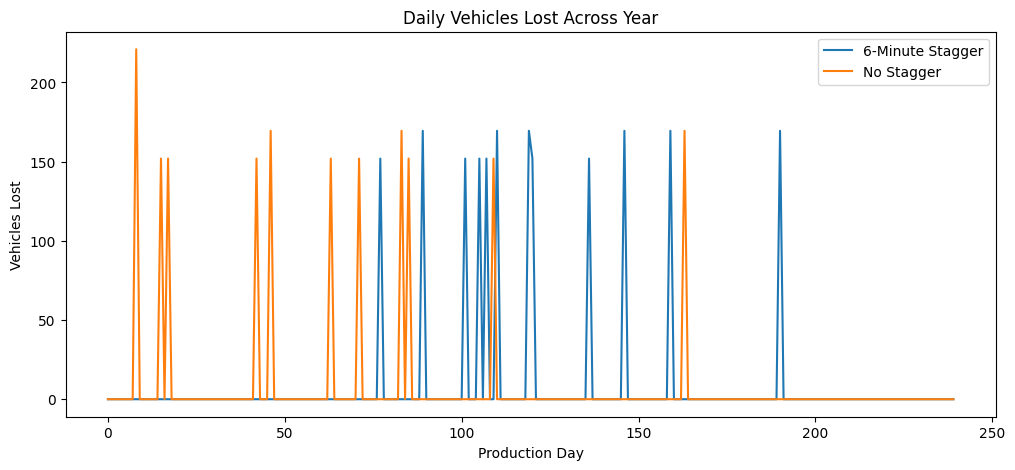

In [156]:
import numpy as np
import matplotlib.pyplot as plt
import random

# ==========================
# Plant parameters
# ==========================

apollo_takt = 75
discovery_takt = 78

apollo_rate = 60 / apollo_takt
discovery_rate = 60 / discovery_takt

shift_end = 15*60 + 45

truck_interval = 180
truck_parts = 300

starting_inventory = 180
expected_output = 701

corridors = ["North","South","East","West"]

corridor_loss_tracker = {
    "North":0,
    "South":0,
    "East":0,
    "West":0
}

# ==========================
# Production calendar
# ==========================

season_calendar = (
    ["Winter"]*60 +
    ["Spring"]*60 +
    ["Summer"]*60 +
    ["Fall"]*60
)

# ==========================
# Seasonal weather generator
# ==========================

def generate_storm(season):

    r = random.random()

    if season == "Winter":

        if r < 0.15:
            return ("Ice Storm", random.choice([240,300]), random.choice(corridors))
        elif r < 0.25:
            return ("Severe Storm", random.choice([120,180]), random.choice(corridors))
        else:
            return ("None",0,None)

    if season == "Spring":

        if r < 0.20:
            return ("Tornado Outbreak", random.choice([240,300,360]), random.choice(corridors))
        elif r < 0.35:
            return ("Severe Storm", random.choice([120,180]), random.choice(corridors))
        else:
            return ("None",0,None)

    if season == "Summer":

        if r < 0.25:
            return ("Thunderstorm",60,random.choice(corridors))
        else:
            return ("None",0,None)

    if season == "Fall":

        if r < 0.10:
            return ("Thunderstorm",60,random.choice(corridors))
        else:
            return ("None",0,None)

    return ("None",0,None)

# ==========================
# Single day simulation
# ==========================

def simulate_day(apollo_start, discovery_start, season):

    inventory = starting_inventory
    vehicles = 0

    storm_type, duration, corridor_hit = generate_storm(season)

    if storm_type != "None":
        storm_start = random.randint(480,720)
        storm_end = storm_start + duration
    else:
        storm_start = -1
        storm_end = -1

    for minute in range(1440):

        apollo_running = apollo_start <= minute < shift_end
        discovery_running = discovery_start <= minute < shift_end

        apollo_prod = apollo_rate if apollo_running else 0
        discovery_prod = discovery_rate if discovery_running else 0

        total_prod = apollo_prod + discovery_prod

        if inventory >= total_prod:

            vehicles += total_prod
            inventory -= total_prod

        else:

            vehicles += inventory
            inventory = 0

        if minute > 0 and minute % truck_interval == 0 and apollo_start <= minute < shift_end:

            corridor = random.choice(corridors)

            blocked = (
                storm_start <= minute <= storm_end
                and corridor == corridor_hit
            )

            if not blocked:
                inventory += truck_parts

    return max(0, expected_output - vehicles)

# ==========================
# Year simulation
# ==========================

def simulate_year(apollo_start, discovery_start):

    losses = []

    for season in season_calendar:

        loss = simulate_day(apollo_start, discovery_start, season)

        losses.append(loss)

    return losses

# ==========================
# Run both scenarios
# ==========================

loss_stagger = simulate_year(7*60+8, 7*60+14)
loss_no_stagger = simulate_year(7*60+8, 7*60+8)

# ==========================
# Results
# ==========================

print("\nScenario A: 6-Minute Stagger")
print("Average vehicles lost/day:", round(np.mean(loss_stagger),1))
print("Worst day:", round(max(loss_stagger),1))
print("Annual vehicles lost:", round(sum(loss_stagger),1))

print("\nScenario B: No Stagger")
print("Average vehicles lost/day:", round(np.mean(loss_no_stagger),1))
print("Worst day:", round(max(loss_no_stagger),1))
print("Annual vehicles lost:", round(sum(loss_no_stagger),1))

# ==========================
# Histogram comparison
# ==========================

plt.figure(figsize=(10,5))

plt.hist(loss_stagger,bins=25,alpha=0.7,label="6-Minute Stagger")
plt.hist(loss_no_stagger,bins=25,alpha=0.7,label="No Stagger")

plt.title("Vehicles Lost Per Day")
plt.xlabel("Vehicles Lost")
plt.ylabel("Frequency")

plt.legend()
plt.show()

# ==========================
# Year timeline
# ==========================

plt.figure(figsize=(12,5))

plt.plot(loss_stagger,label="6-Minute Stagger")
plt.plot(loss_no_stagger,label="No Stagger")

plt.title("Daily Vehicles Lost Across Year")
plt.xlabel("Production Day")
plt.ylabel("Vehicles Lost")

plt.legend()
plt.show()

In [157]:
print(corridor_loss_tracker)

{'North': 0, 'South': 0, 'East': 0, 'West': 0}


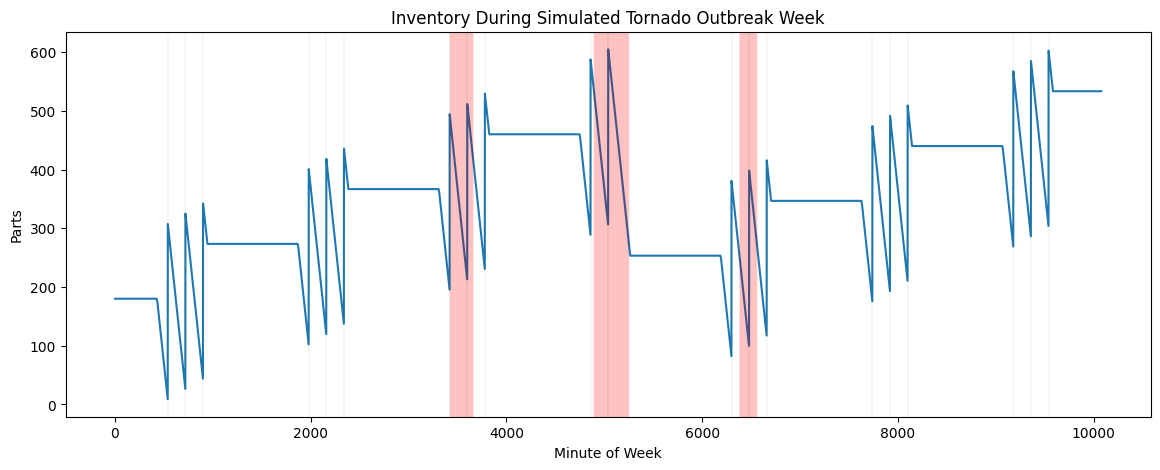

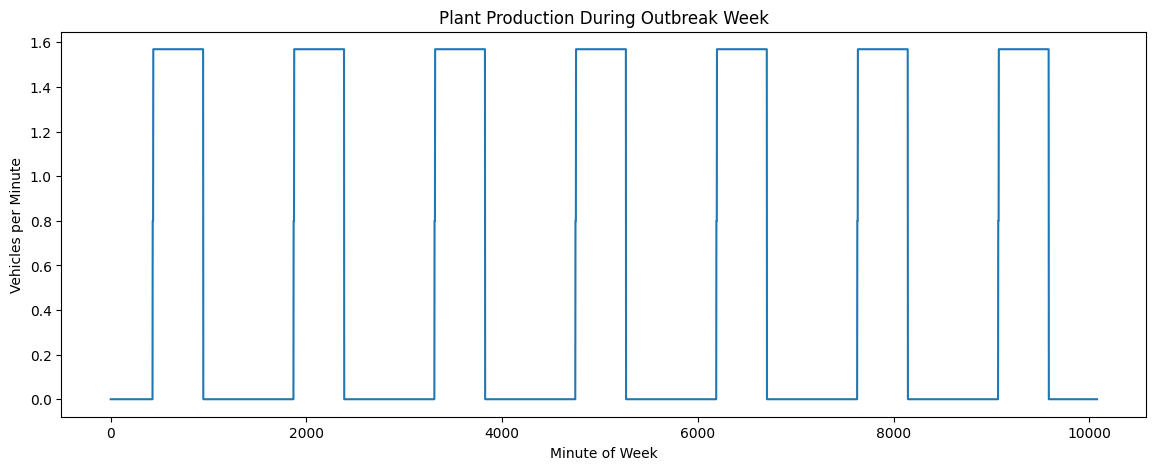

In [168]:
import numpy as np
import matplotlib.pyplot as plt
import random

# ==========================
# Plant parameters
# ==========================

apollo_takt = 75
discovery_takt = 78

apollo_rate = 60 / apollo_takt
discovery_rate = 60 / discovery_takt

apollo_start = 7*60 + 8
discovery_start = 7*60 + 14
shift_end = 15*60 + 45

truck_interval = 180
truck_parts = 300

starting_inventory = 180

corridors = ["North","South","East","West"]

corridor_weights = [0.4, 0.2, 0.25, 0.15]

corridor_loss_tracker = {
    "North":0,
    "South":0,
    "East":0,
    "West":0
}

# ==========================
# Simulated outbreak week
# ==========================

storm_days = {
    2:("Severe Storm",240,"North"),
    3:("Tornado Outbreak",360,"North"),
    4:("Severe Storm",180,"North")
}

# ==========================
# Simulation
# ==========================

inventory = starting_inventory

minutes = []
inventory_trace = []
production_trace = []
truck_events = []
storm_trace = []

for day in range(7):

    if day in storm_days:
        storm_type, duration, corridor_hit = storm_days[day]
        storm_start = random.randint(480,720)
        storm_end = storm_start + duration
    else:
        storm_start = -1
        storm_end = -1
        corridor_hit = None

    for minute in range(1440):

        global_minute = day*1440 + minute

        apollo_running = apollo_start <= minute < shift_end
        discovery_running = discovery_start <= minute < shift_end

        apollo_prod = apollo_rate if apollo_running else 0
        discovery_prod = discovery_rate if discovery_running else 0

        total_prod = apollo_prod + discovery_prod

        if inventory >= total_prod:
            production = total_prod
            inventory -= total_prod
        else:
            production = inventory
            inventory = 0

        # truck deliveries
        if minute > 0 and minute % truck_interval == 0 and apollo_start <= minute < shift_end:

            corridor_hit = random.choices(corridors, weights=corridor_weights)[0]

            blocked = (
                storm_start <= minute <= storm_end
                and corridor == corridor_hit
            )

            if not blocked:
                inventory += truck_parts
                truck_events.append(global_minute)

        minutes.append(global_minute)
        inventory_trace.append(inventory)
        production_trace.append(production)

        if storm_start <= minute <= storm_end:
            storm_trace.append(global_minute)

# ==========================
# Inventory plot
# ==========================

plt.figure(figsize=(14,5))

plt.plot(minutes,inventory_trace,label="Inventory")

for t in truck_events:
    plt.axvline(t,alpha=0.05,color="green")

for s in storm_trace:
    plt.axvline(s,alpha=0.01,color="red")

plt.title("Inventory During Simulated Tornado Outbreak Week")
plt.xlabel("Minute of Week")
plt.ylabel("Parts")

plt.show()

# ==========================
# Production plot
# ==========================

plt.figure(figsize=(14,5))

plt.plot(minutes,production_trace,label="Production Rate")

plt.title("Plant Production During Outbreak Week")
plt.xlabel("Minute of Week")
plt.ylabel("Vehicles per Minute")

plt.show()

In [159]:
# ==========================
# Disruption analysis
# ==========================

import numpy as np

def analyze_losses(losses, label):

    losses = np.array(losses)

    disruption_days = losses > 0
    severe_days = losses > 200
    catastrophic_days = losses > 350

    print("\n",label)
    print("---------------------------")

    print("Total production days:", len(losses))
    print("Disruption days:", disruption_days.sum())
    print("Severe disruption days (>200 vehicles lost):", severe_days.sum())
    print("Catastrophic days (>350 vehicles lost):", catastrophic_days.sum())

    print("\nPercent of days disrupted:",
          round(100 * disruption_days.sum() / len(losses),2),"%")

    if disruption_days.sum() > 0:
        print("Average loss on disruption days:",
              round(losses[disruption_days].mean(),1))

    print("Worst disruption:", round(losses.max(),1))


analyze_losses(loss_stagger,"6-Minute Stagger Scenario")
analyze_losses(loss_no_stagger,"No-Stagger Scenario")


 6-Minute Stagger Scenario
---------------------------
Total production days: 240
Disruption days: 12
Severe disruption days (>200 vehicles lost): 0
Catastrophic days (>350 vehicles lost): 0

Percent of days disrupted: 5.0 %
Average loss on disruption days: 160.7
Worst disruption: 169.5

 No-Stagger Scenario
---------------------------
Total production days: 240
Disruption days: 11
Severe disruption days (>200 vehicles lost): 1
Catastrophic days (>350 vehicles lost): 0

Percent of days disrupted: 4.58 %
Average loss on disruption days: 163.0
Worst disruption: 221.0


In [160]:
print(truck_parts)

300


In [161]:
season_losses = {"Winter":0,"Spring":0,"Summer":0,"Fall":0}

for i,loss in enumerate(loss_stagger):
    season = season_calendar[i]
    if loss > 0:
        season_losses[season] += 1

print(season_losses)

{'Winter': 0, 'Spring': 7, 'Summer': 4, 'Fall': 1}


In [162]:
# ==========================
# Multi-year Monte Carlo test
# ==========================

years = 1000

stagger_results = []
nostagger_results = []

for y in range(years):

    stagger_year = sum(simulate_year(7*60+8, 7*60+14))
    nostagger_year = sum(simulate_year(7*60+8, 7*60+8))

    stagger_results.append(stagger_year)
    nostagger_results.append(nostagger_year)

print("Average annual vehicles lost (Stagger):", round(np.mean(stagger_results),1))
print("Average annual vehicles lost (No Stagger):", round(np.mean(nostagger_results),1))

print("\nWorst simulated year (Stagger):", round(max(stagger_results),1))
print("Worst simulated year (No Stagger):", round(max(nostagger_results),1))

Average annual vehicles lost (Stagger): 2039.4
Average annual vehicles lost (No Stagger): 2067.4

Worst simulated year (Stagger): 4121.2
Worst simulated year (No Stagger): 4134.8


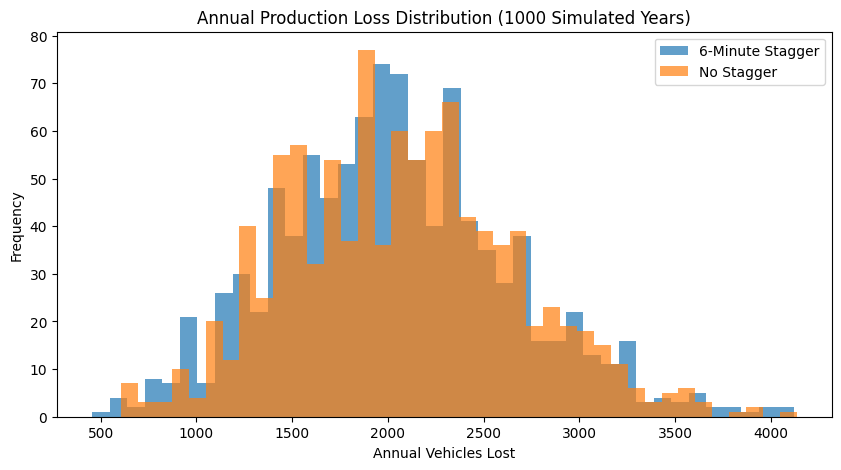

In [163]:
plt.figure(figsize=(10,5))

plt.hist(stagger_results,bins=40,alpha=0.7,label="6-Minute Stagger")
plt.hist(nostagger_results,bins=40,alpha=0.7,label="No Stagger")

plt.xlabel("Annual Vehicles Lost")
plt.ylabel("Frequency")
plt.title("Annual Production Loss Distribution (1000 Simulated Years)")

plt.legend()
plt.show()

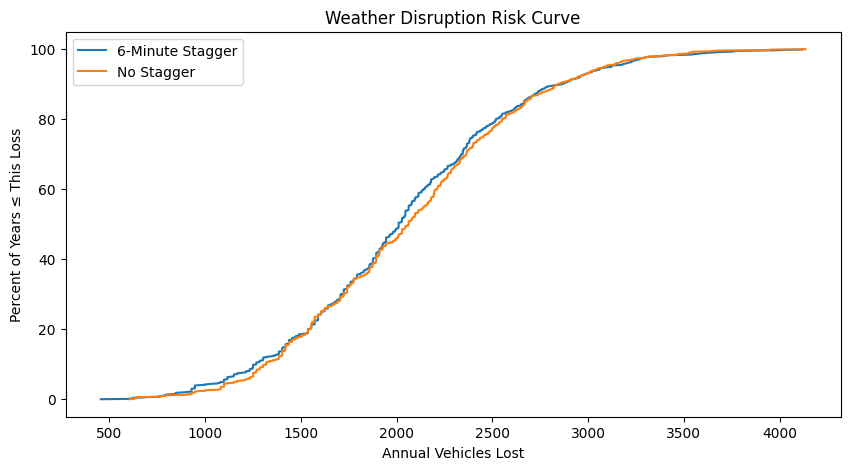

In [164]:
# ==========================
# Annual risk probability curve
# ==========================

import numpy as np
import matplotlib.pyplot as plt

stagger = np.array(stagger_results)
nostagger = np.array(nostagger_results)

# Sort for cumulative probability
stagger_sorted = np.sort(stagger)
nostagger_sorted = np.sort(nostagger)

prob = np.linspace(0,100,len(stagger_sorted))

plt.figure(figsize=(10,5))

plt.plot(stagger_sorted,prob,label="6-Minute Stagger")
plt.plot(nostagger_sorted,prob,label="No Stagger")

plt.xlabel("Annual Vehicles Lost")
plt.ylabel("Percent of Years ≤ This Loss")
plt.title("Weather Disruption Risk Curve")

plt.legend()

plt.show()

In [165]:
print("90th percentile loss:", np.percentile(stagger,90))
print("95th percentile loss:", np.percentile(stagger,95))
print("99th percentile loss:", np.percentile(stagger,99))

90th percentile loss: 2858.983076923046
95th percentile loss: 3122.8615384614973
99th percentile loss: 3630.481999999951


In [166]:
# ==========================
# Corridor disruption tracker
# ==========================

corridor_losses = {
    "North":0,
    "South":0,
    "East":0,
    "West":0
}

corridor_events = {
    "North":0,
    "South":0,
    "East":0,
    "West":0
}

# run additional simulations to track storm corridor effects

years = 1000

for y in range(years):

    for season in season_calendar:

        storm_type, duration, corridor_hit = generate_storm(season)

        if corridor_hit is not None:
            corridor_events[corridor_hit] += 1

            # simulate a day using your baseline model
            loss = simulate_day(7*60+8,7*60+14,season)

            corridor_losses[corridor_hit] += loss

print("Storm events by corridor:")
print(corridor_events)

print("\nVehicles lost by corridor:")
print(corridor_losses)

Storm events by corridor:
{'North': 14167, 'South': 14250, 'East': 14045, 'West': 14396}

Vehicles lost by corridor:
{'North': 150281.78461538278, 'South': 157468.3076923048, 'East': 138146.44615384447, 'West': 145767.41538461336}


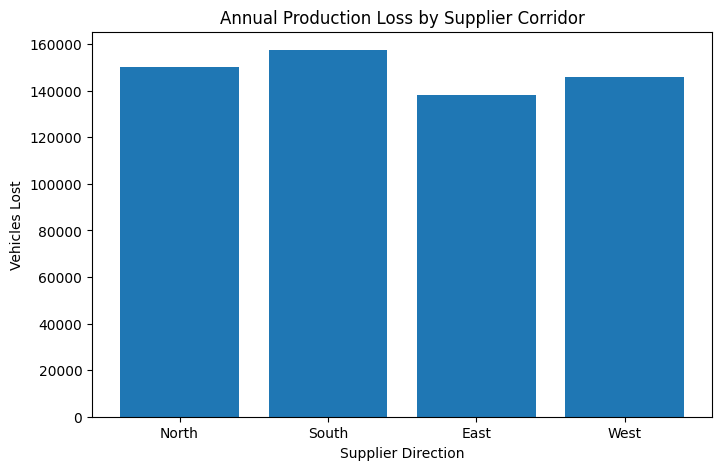

In [167]:
# ==========================
# Corridor disruption chart
# ==========================

import matplotlib.pyplot as plt

corridors = list(corridor_losses.keys())
loss_values = list(corridor_losses.values())

plt.figure(figsize=(8,5))

plt.bar(corridors,loss_values)

plt.title("Annual Production Loss by Supplier Corridor")
plt.xlabel("Supplier Direction")
plt.ylabel("Vehicles Lost")

plt.show()

In [169]:
import numpy as np
import matplotlib.pyplot as plt
import random

# ==========================
# Plant parameters
# ==========================

apollo_takt = 75
discovery_takt = 78

apollo_rate = 60 / apollo_takt
discovery_rate = 60 / discovery_takt

shift_end = 15 * 60 + 45

truck_interval = 180
truck_parts = 300
starting_inventory = 180
expected_output = 701

corridors = ["North", "South", "East", "West"]
corridor_weights = [0.40, 0.20, 0.25, 0.15]

season_calendar = (
    ["Winter"] * 60 +
    ["Spring"] * 60 +
    ["Summer"] * 60 +
    ["Fall"] * 60
)

# ==========================
# Weighted seasonal storm generator
# ==========================

def generate_storm(season):
    r = random.random()

    if season == "Winter":
        if r < 0.15:
            return ("Ice Storm", random.choice([240, 300]), random.choices(corridors, weights=corridor_weights)[0])
        elif r < 0.25:
            return ("Severe Storm", random.choice([120, 180]), random.choices(corridors, weights=corridor_weights)[0])
        else:
            return ("None", 0, None)

    if season == "Spring":
        if r < 0.20:
            return ("Tornado Outbreak", random.choice([240, 300, 360]), random.choices(corridors, weights=corridor_weights)[0])
        elif r < 0.35:
            return ("Severe Storm", random.choice([120, 180]), random.choices(corridors, weights=corridor_weights)[0])
        else:
            return ("None", 0, None)

    if season == "Summer":
        if r < 0.25:
            return ("Thunderstorm", 60, random.choices(corridors, weights=corridor_weights)[0])
        else:
            return ("None", 0, None)

    if season == "Fall":
        if r < 0.10:
            return ("Thunderstorm", 60, random.choices(corridors, weights=corridor_weights)[0])
        else:
            return ("None", 0, None)

    return ("None", 0, None)

# ==========================
# Single-day simulation
# Returns daily loss + corridor that caused it
# ==========================

def simulate_day(apollo_start, discovery_start, season):
    inventory = starting_inventory
    vehicles = 0.0

    storm_type, duration, corridor_hit = generate_storm(season)

    if storm_type != "None":
        storm_start = random.randint(480, 720)
        storm_end = storm_start + duration
    else:
        storm_start = -1
        storm_end = -1

    for minute in range(1440):
        apollo_running = apollo_start <= minute < shift_end
        discovery_running = discovery_start <= minute < shift_end

        apollo_prod = apollo_rate if apollo_running else 0.0
        discovery_prod = discovery_rate if discovery_running else 0.0
        total_prod = apollo_prod + discovery_prod

        if inventory >= total_prod:
            vehicles += total_prod
            inventory -= total_prod
        else:
            vehicles += inventory
            inventory = 0.0

        if minute > 0 and minute % truck_interval == 0 and apollo_start <= minute < shift_end:
            # truck route also has corridor structure
            truck_corridor = random.choices(corridors, weights=corridor_weights)[0]

            blocked = (
                storm_start <= minute <= storm_end and
                truck_corridor == corridor_hit
            )

            if not blocked:
                inventory += truck_parts

    daily_loss = max(0.0, expected_output - vehicles)
    return daily_loss, corridor_hit

# ==========================
# Year simulation with corridor tracking
# ==========================

def simulate_year_with_corridors(apollo_start, discovery_start):
    losses = []
    corridor_loss = {c: 0.0 for c in corridors}
    corridor_events = {c: 0 for c in corridors}

    for season in season_calendar:
        daily_loss, corridor_hit = simulate_day(apollo_start, discovery_start, season)
        losses.append(daily_loss)

        if corridor_hit is not None:
            corridor_events[corridor_hit] += 1
            corridor_loss[corridor_hit] += daily_loss

    return losses, corridor_loss, corridor_events

In [170]:
loss_stagger, corridor_loss_stagger, corridor_events_stagger = simulate_year_with_corridors(7*60+8, 7*60+14)
loss_no_stagger, corridor_loss_no_stagger, corridor_events_no_stagger = simulate_year_with_corridors(7*60+8, 7*60+8)

print("6-Minute Stagger annual loss:", round(sum(loss_stagger), 1))
print("No-Stagger annual loss:", round(sum(loss_no_stagger), 1))

print("\nStagger corridor events:")
print(corridor_events_stagger)

print("\nStagger corridor loss:")
print({k: round(v,1) for k,v in corridor_loss_stagger.items()})

6-Minute Stagger annual loss: 3854.9
No-Stagger annual loss: 3073.9

Stagger corridor events:
{'North': 29, 'South': 12, 'East': 19, 'West': 7}

Stagger corridor loss:
{'North': 2379.5, 'South': 390.5, 'East': 932.9, 'West': 152.0}


In [171]:
loss_stagger, corridor_loss_stagger, corridor_events_stagger = simulate_year_with_corridors(7*60+8, 7*60+14)
loss_no_stagger, corridor_loss_no_stagger, corridor_events_no_stagger = simulate_year_with_corridors(7*60+8, 7*60+8)

print("6-Minute Stagger annual loss:", round(sum(loss_stagger), 1))
print("No-Stagger annual loss:", round(sum(loss_no_stagger), 1))

print("\nStagger corridor events:")
print(corridor_events_stagger)

print("\nStagger corridor loss:")
print({k: round(v,1) for k,v in corridor_loss_stagger.items()})

6-Minute Stagger annual loss: 2992.4
No-Stagger annual loss: 2193.6

Stagger corridor events:
{'North': 19, 'South': 11, 'East': 18, 'West': 9}

Stagger corridor loss:
{'North': 1402.7, 'South': 473.4, 'East': 794.8, 'West': 321.4}


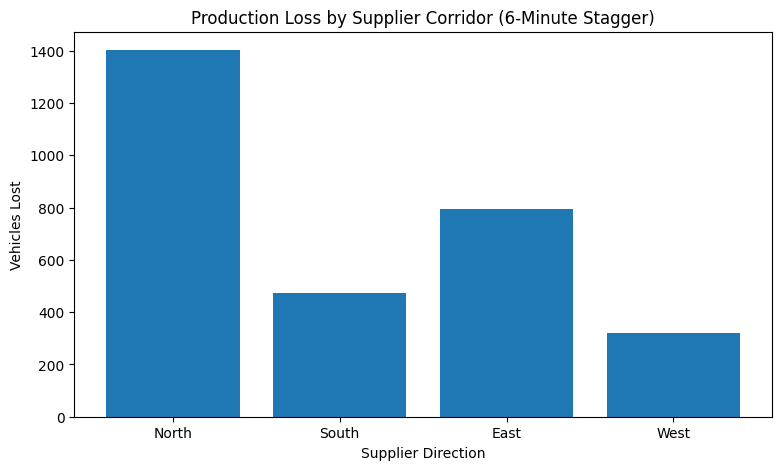

In [172]:
plt.figure(figsize=(9,5))
plt.bar(corridor_loss_stagger.keys(), corridor_loss_stagger.values())
plt.title("Production Loss by Supplier Corridor (6-Minute Stagger)")
plt.xlabel("Supplier Direction")
plt.ylabel("Vehicles Lost")
plt.show()

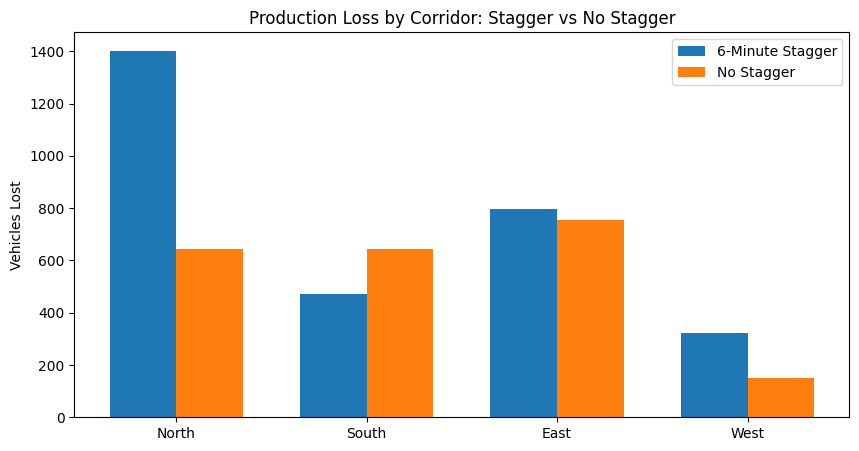

In [173]:
x = np.arange(len(corridors))
width = 0.35

stagger_vals = [corridor_loss_stagger[c] for c in corridors]
nostagger_vals = [corridor_loss_no_stagger[c] for c in corridors]

plt.figure(figsize=(10,5))
plt.bar(x - width/2, stagger_vals, width, label="6-Minute Stagger")
plt.bar(x + width/2, nostagger_vals, width, label="No Stagger")
plt.xticks(x, corridors)
plt.title("Production Loss by Corridor: Stagger vs No Stagger")
plt.ylabel("Vehicles Lost")
plt.legend()
plt.show()

{'North': 1352.9, 'South': 342.9, 'East': 499.7, 'West': 177.2}


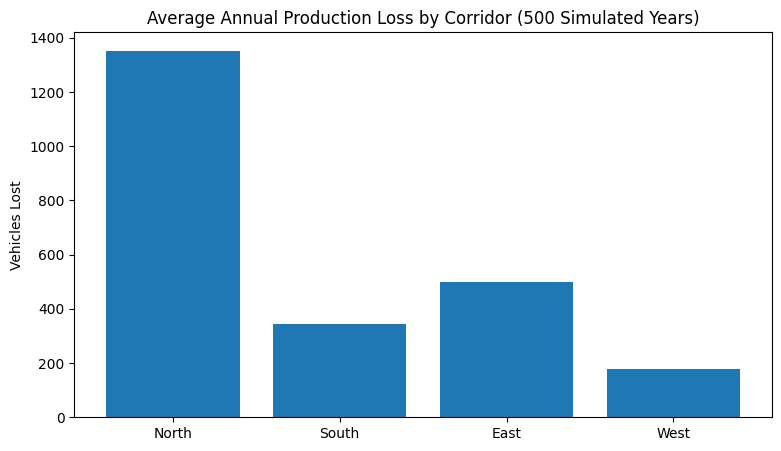

In [174]:
years = 500

avg_corridor_loss = {c: 0.0 for c in corridors}

for _ in range(years):
    _, corridor_loss_tmp, _ = simulate_year_with_corridors(7*60+8, 7*60+14)
    for c in corridors:
        avg_corridor_loss[c] += corridor_loss_tmp[c]

for c in corridors:
    avg_corridor_loss[c] /= years

print({k: round(v,1) for k,v in avg_corridor_loss.items()})

plt.figure(figsize=(9,5))
plt.bar(avg_corridor_loss.keys(), avg_corridor_loss.values())
plt.title("Average Annual Production Loss by Corridor (500 Simulated Years)")
plt.ylabel("Vehicles Lost")
plt.show()

In [175]:
# ==========================
# Inventory buffer experiment
# ==========================

buffers = [120, 180, 240, 300, 360, 420]  # parts in buffer
years = 200

buffer_results = []

for buffer in buffers:

    total_loss = 0

    for y in range(years):

        starting_inventory = buffer
        losses, _, _ = simulate_year_with_corridors(7*60+8, 7*60+14)

        total_loss += sum(losses)

    avg_loss = total_loss / years
    buffer_results.append(avg_loss)

print("Average annual vehicles lost:")
for b, loss in zip(buffers, buffer_results):
    print(f"Buffer {b}: {round(loss,1)}")

Average annual vehicles lost:
Buffer 120: 3190.8
Buffer 180: 2340.3
Buffer 240: 1504.2
Buffer 300: 747.4
Buffer 360: 178.0
Buffer 420: 103.9


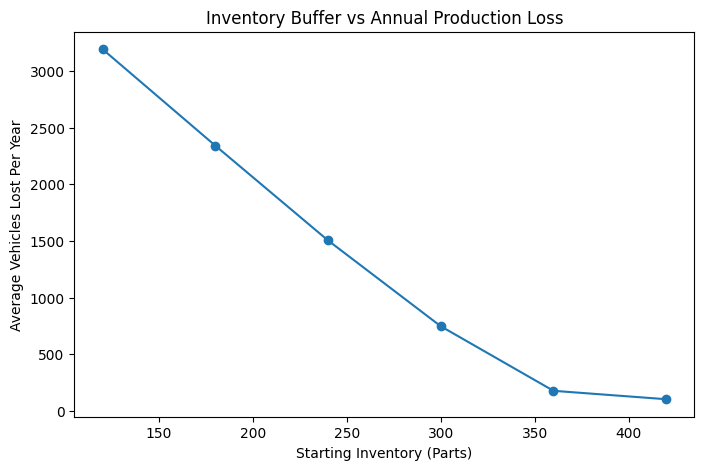

In [176]:
plt.figure(figsize=(8,5))

plt.plot(buffers, buffer_results, marker='o')

plt.title("Inventory Buffer vs Annual Production Loss")
plt.xlabel("Starting Inventory (Parts)")
plt.ylabel("Average Vehicles Lost Per Year")

plt.show()

In [177]:
# ==========================
# Supply chain resilience heatmap
# ==========================

buffers = [120,180,240,300,360,420]
truck_intervals = [120,150,180,210,240]

years = 120

heatmap = []

for buffer in buffers:

    row = []

    for interval in truck_intervals:

        total_loss = 0

        for y in range(years):

            starting_inventory = buffer
            truck_interval = interval

            losses, _, _ = simulate_year_with_corridors(7*60+8,7*60+14)

            total_loss += sum(losses)

        avg_loss = total_loss / years
        row.append(avg_loss)

    heatmap.append(row)

heatmap = np.array(heatmap)

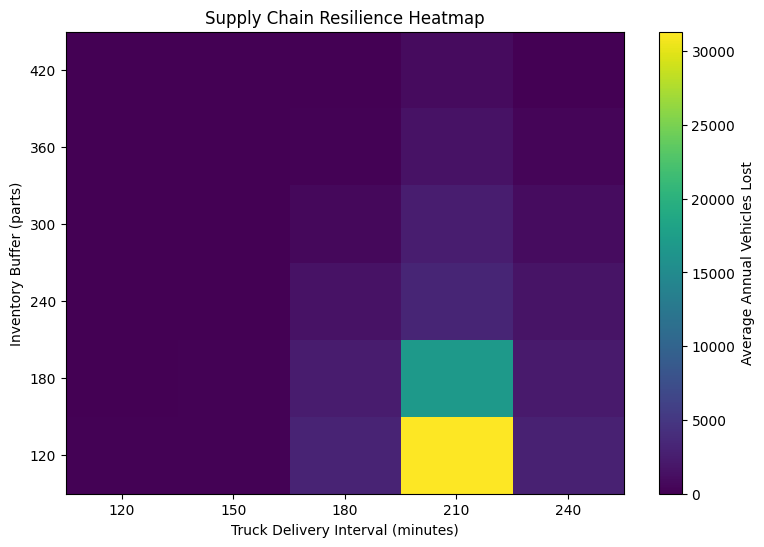

In [178]:
plt.figure(figsize=(9,6))

plt.imshow(heatmap,aspect='auto',origin='lower')

plt.colorbar(label="Average Annual Vehicles Lost")

plt.xticks(range(len(truck_intervals)),truck_intervals)
plt.yticks(range(len(buffers)),buffers)

plt.xlabel("Truck Delivery Interval (minutes)")
plt.ylabel("Inventory Buffer (parts)")

plt.title("Supply Chain Resilience Heatmap")

plt.show()

In [179]:
# ==========================
# Annual disruption risk distribution
# ==========================

years = 1000
annual_losses = []

for y in range(years):

    losses, _, _ = simulate_year_with_corridors(7*60+8, 7*60+14)

    annual_losses.append(sum(losses))

annual_losses = np.array(annual_losses)

print("Average annual loss:", round(np.mean(annual_losses),1))
print("Median year:", round(np.percentile(annual_losses,50),1))
print("90th percentile year:", round(np.percentile(annual_losses,90),1))
print("95th percentile year:", round(np.percentile(annual_losses,95),1))
print("Worst simulated year:", round(np.max(annual_losses),1))

Average annual loss: 3.1
Median year: 0.0
90th percentile year: 0.0
95th percentile year: 0.0
Worst simulated year: 281.0


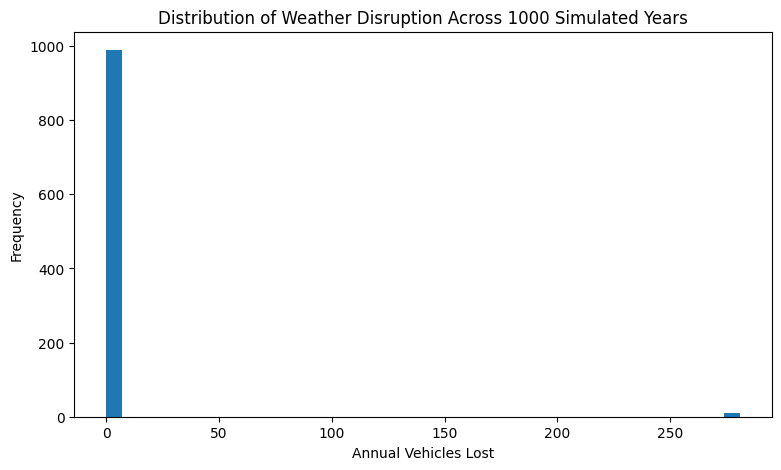

In [180]:
plt.figure(figsize=(9,5))

plt.hist(annual_losses,bins=40)

plt.xlabel("Annual Vehicles Lost")
plt.ylabel("Frequency")
plt.title("Distribution of Weather Disruption Across 1000 Simulated Years")

plt.show()

In [181]:
# ==========================
# Tornado outbreak week simulation
# ==========================

inventory = starting_inventory
minutes = []
inventory_trace = []
production_trace = []

storm_start = 600
storm_duration = 360
storm_end = storm_start + storm_duration
corridor_hit = "North"

vehicles = 0

for minute in range(1440):

    apollo_running = 7*60+8 <= minute < shift_end
    discovery_running = 7*60+14 <= minute < shift_end

    apollo_prod = apollo_rate if apollo_running else 0
    discovery_prod = discovery_rate if discovery_running else 0

    total_prod = apollo_prod + discovery_prod

    if inventory >= total_prod:
        vehicles += total_prod
        inventory -= total_prod
    else:
        vehicles += inventory
        inventory = 0

    if minute > 0 and minute % truck_interval == 0 and apollo_running:

        truck_corridor = random.choices(corridors,weights=corridor_weights)[0]

        blocked = (
            storm_start <= minute <= storm_end
            and truck_corridor == corridor_hit
        )

        if not blocked:
            inventory += truck_parts

    minutes.append(minute)
    inventory_trace.append(inventory)
    production_trace.append(total_prod if inventory>0 else 0)

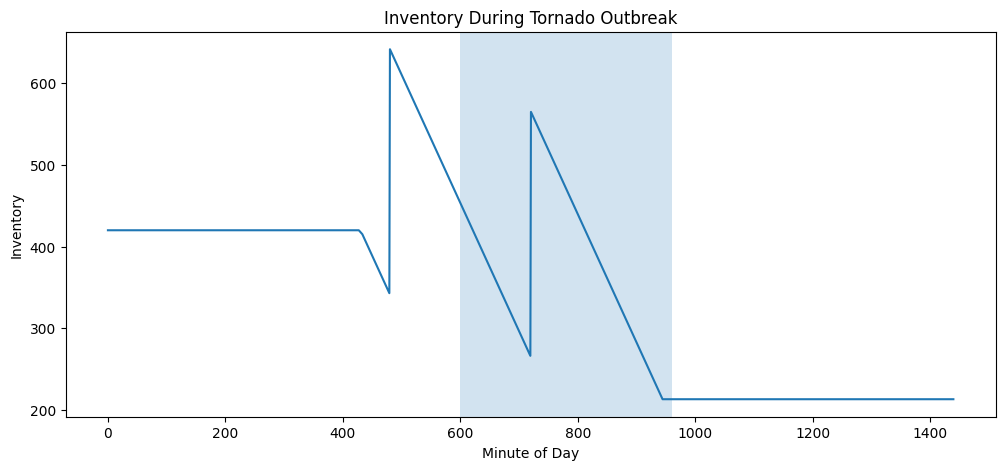

In [182]:
plt.figure(figsize=(12,5))

plt.plot(minutes,inventory_trace)

plt.axvspan(storm_start,storm_end,alpha=0.2)

plt.xlabel("Minute of Day")
plt.ylabel("Inventory")
plt.title("Inventory During Tornado Outbreak")

plt.show()

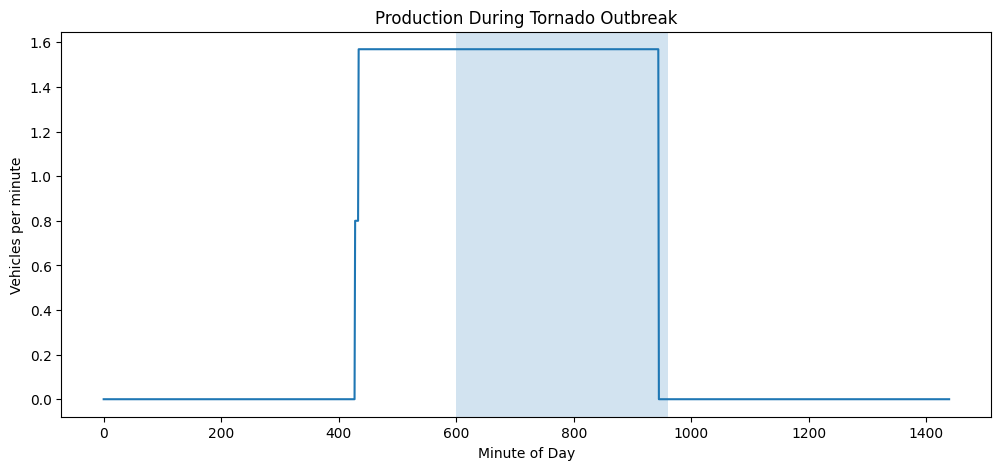

In [183]:
plt.figure(figsize=(12,5))

plt.plot(minutes,production_trace)

plt.axvspan(storm_start,storm_end,alpha=0.2)

plt.xlabel("Minute of Day")
plt.ylabel("Vehicles per minute")
plt.title("Production During Tornado Outbreak")

plt.show()

In [184]:
# ==========================
# Two-shift North corridor shutdown simulation
# ==========================

simulation_minutes = 72 * 60   # 3 days

inventory = starting_inventory
vehicles = 0

minutes = []
inventory_trace = []
production_trace = []

# North corridor shutdown
shutdown_start = 12 * 60
shutdown_duration = 48 * 60
shutdown_end = shutdown_start + shutdown_duration

for minute in range(simulation_minutes):

    minute_of_day = minute % 1440

    # two shifts
    apollo_running = (
        7*60+8 <= minute_of_day < shift_end
        or 19*60+8 <= minute_of_day < 24*60
        or 0 <= minute_of_day < 3*60+45
    )

    discovery_running = (
        7*60+14 <= minute_of_day < shift_end
        or 19*60+14 <= minute_of_day < 24*60
        or 0 <= minute_of_day < 3*60+45
    )

    apollo_prod = apollo_rate if apollo_running else 0
    discovery_prod = discovery_rate if discovery_running else 0

    total_prod = apollo_prod + discovery_prod

    if inventory >= total_prod:
        vehicles += total_prod
        inventory -= total_prod
    else:
        vehicles += inventory
        inventory = 0

    # truck arrivals
    if minute > 0 and minute % truck_interval == 0 and apollo_running:

        truck_corridor = random.choices(corridors,weights=corridor_weights)[0]

        blocked = (
            shutdown_start <= minute <= shutdown_end
            and truck_corridor == "North"
        )

        if not blocked:
            inventory += truck_parts

    minutes.append(minute)
    inventory_trace.append(inventory)
    production_trace.append(total_prod if inventory>0 else 0)

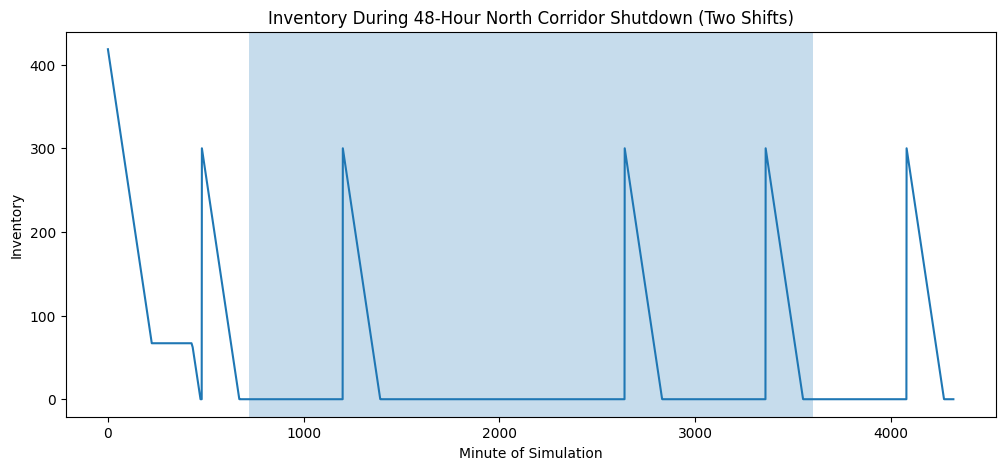

In [185]:
plt.figure(figsize=(12,5))

plt.plot(minutes,inventory_trace)

plt.axvspan(shutdown_start,shutdown_end,alpha=0.25)

plt.xlabel("Minute of Simulation")
plt.ylabel("Inventory")
plt.title("Inventory During 48-Hour North Corridor Shutdown (Two Shifts)")

plt.show()

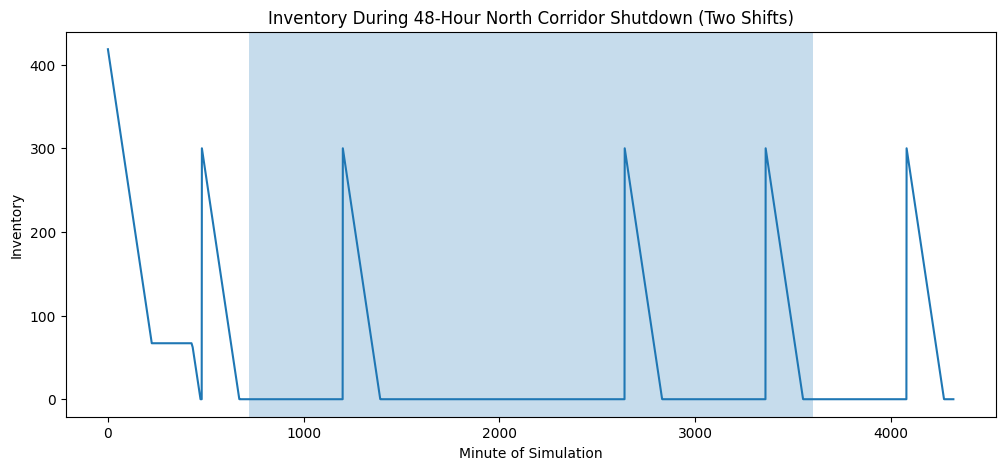

In [186]:
plt.figure(figsize=(12,5))

plt.plot(minutes,inventory_trace)

plt.axvspan(shutdown_start,shutdown_end,alpha=0.25)

plt.xlabel("Minute of Simulation")
plt.ylabel("Inventory")
plt.title("Inventory During 48-Hour North Corridor Shutdown (Two Shifts)")

plt.show()

In [187]:
# ==========================
# Time-to-shutdown calculator
# ==========================

inventory = starting_inventory
vehicles = 0

shutdown_minute = None

for minute in range(simulation_minutes):

    minute_of_day = minute % 1440

    apollo_running = (
        7*60+8 <= minute_of_day < shift_end
        or 19*60+8 <= minute_of_day < 24*60
        or 0 <= minute_of_day < 3*60+45
    )

    discovery_running = (
        7*60+14 <= minute_of_day < shift_end
        or 19*60+14 <= minute_of_day < 24*60
        or 0 <= minute_of_day < 3*60+45
    )

    apollo_prod = apollo_rate if apollo_running else 0
    discovery_prod = discovery_rate if discovery_running else 0

    total_prod = apollo_prod + discovery_prod

    if inventory >= total_prod:
        inventory -= total_prod
    else:
        if shutdown_minute is None:
            shutdown_minute = minute
        inventory = 0

    if minute > 0 and minute % truck_interval == 0 and apollo_running:

        truck_corridor = random.choices(corridors,weights=corridor_weights)[0]

        blocked = (
            shutdown_start <= minute <= shutdown_end
            and truck_corridor == "North"
        )

        if not blocked:
            inventory += truck_parts

In [188]:
if shutdown_minute is not None:

    survival_minutes = shutdown_minute - shutdown_start
    survival_hours = survival_minutes / 60

    print("Plant survived", round(survival_hours,2), "hours after supply cutoff")

else:

    print("Plant never shut down during the simulation")

Plant survived -4.12 hours after supply cutoff


In [191]:
# ==========================
# Supply chain survival curve
# ==========================

buffers = [120,180,240,300,360,420]

survival_times = []

for buffer in buffers:

    inventory = buffer
    shutdown_minute = None

    for minute in range(simulation_minutes):

        minute_of_day = minute % 1440

        apollo_running = (
            7*60+8 <= minute_of_day < shift_end
            or 19*60+8 <= minute_of_day < 24*60
            or 0 <= minute_of_day < 3*60+45
        )

        discovery_running = (
            7*60+14 <= minute_of_day < shift_end
            or 19*60+14 <= minute_of_day < 24*60
            or 0 <= minute_of_day < 3*60+45
        )

        apollo_prod = apollo_rate if apollo_running else 0
        discovery_prod = discovery_rate if discovery_running else 0

        total_prod = apollo_prod + discovery_prod

        if inventory >= total_prod:
            inventory -= total_prod
        else:
            shutdown_minute = minute
            break

    if shutdown_minute is not None:
        survival_hours = shutdown_minute / 60
        survival_times.append(survival_hours)
    else:
        survival_times.append(None)

print("Survival times (hours):")
for b, s in zip(buffers, survival_times):
    print(f"Buffer {b}: {round(s,2)} hours")

Survival times (hours):
Buffer 120: 1.27 hours
Buffer 180: 1.9 hours
Buffer 240: 2.53 hours
Buffer 300: 3.18 hours
Buffer 360: 7.25 hours
Buffer 420: 7.88 hours


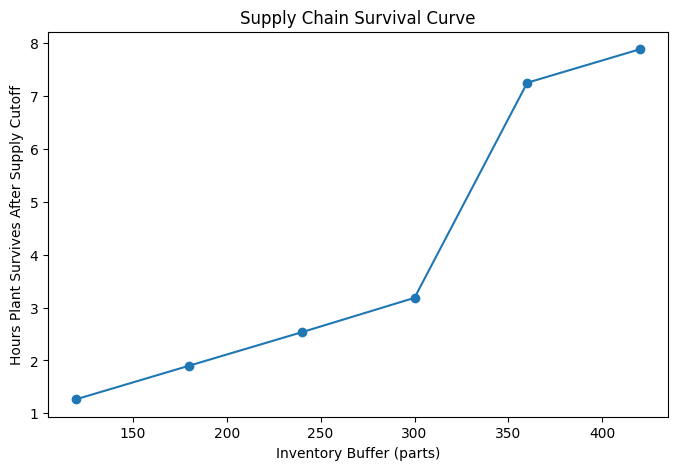

In [192]:
plt.figure(figsize=(8,5))

plt.plot(buffers,survival_times,marker="o")

plt.xlabel("Inventory Buffer (parts)")
plt.ylabel("Hours Plant Survives After Supply Cutoff")
plt.title("Supply Chain Survival Curve")

plt.show()

In [193]:
# ==========================
# 3-day tornado outbreak replay
# ==========================

simulation_minutes = 72 * 60

inventory = starting_inventory

minutes = []
inventory_trace = []
production_trace = []

# storm timeline
storm1_start = 12*60
storm1_end = storm1_start + 180

storm2_start = 24*60 + 10*60
storm2_end = storm2_start + 360

storm3_start = 48*60 + 8*60
storm3_end = storm3_start + 120

for minute in range(simulation_minutes):

    minute_of_day = minute % 1440

    apollo_running = (
        7*60+8 <= minute_of_day < shift_end
        or 19*60+8 <= minute_of_day < 24*60
        or 0 <= minute_of_day < 3*60+45
    )

    discovery_running = (
        7*60+14 <= minute_of_day < shift_end
        or 19*60+14 <= minute_of_day < 24*60
        or 0 <= minute_of_day < 3*60+45
    )

    apollo_prod = apollo_rate if apollo_running else 0
    discovery_prod = discovery_rate if discovery_running else 0

    total_prod = apollo_prod + discovery_prod

    if inventory >= total_prod:
        inventory -= total_prod
    else:
        inventory = 0

    if minute > 0 and minute % truck_interval == 0 and apollo_running:

        truck_corridor = random.choices(corridors,weights=corridor_weights)[0]

        blocked = (
            (storm1_start <= minute <= storm1_end or
             storm2_start <= minute <= storm2_end or
             storm3_start <= minute <= storm3_end)
            and truck_corridor == "North"
        )

        if not blocked:
            inventory += truck_parts

    minutes.append(minute)
    inventory_trace.append(inventory)
    production_trace.append(total_prod if inventory > 0 else 0)

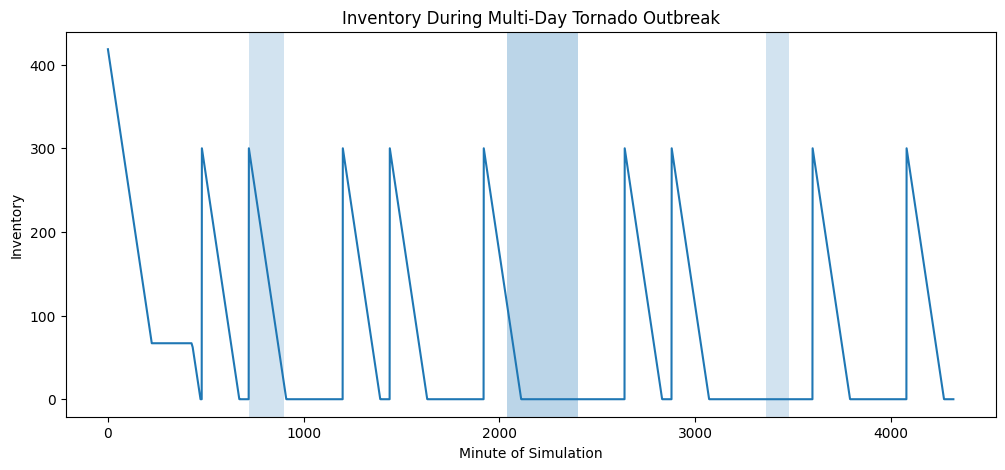

In [194]:
plt.figure(figsize=(12,5))

plt.plot(minutes,inventory_trace)

plt.axvspan(storm1_start,storm1_end,alpha=0.2)
plt.axvspan(storm2_start,storm2_end,alpha=0.3)
plt.axvspan(storm3_start,storm3_end,alpha=0.2)

plt.xlabel("Minute of Simulation")
plt.ylabel("Inventory")
plt.title("Inventory During Multi-Day Tornado Outbreak")

plt.show()

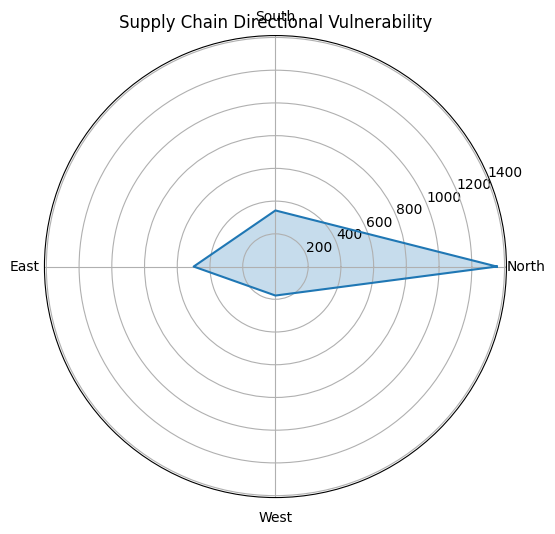

In [195]:
# ==========================
# Supply chain vulnerability radar
# ==========================

labels = list(avg_corridor_loss.keys())
values = list(avg_corridor_loss.values())

values += values[:1]
angles = np.linspace(0,2*np.pi,len(labels),endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, polar=True)

ax.plot(angles,values)
ax.fill(angles,values,alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Supply Chain Directional Vulnerability")

plt.show()

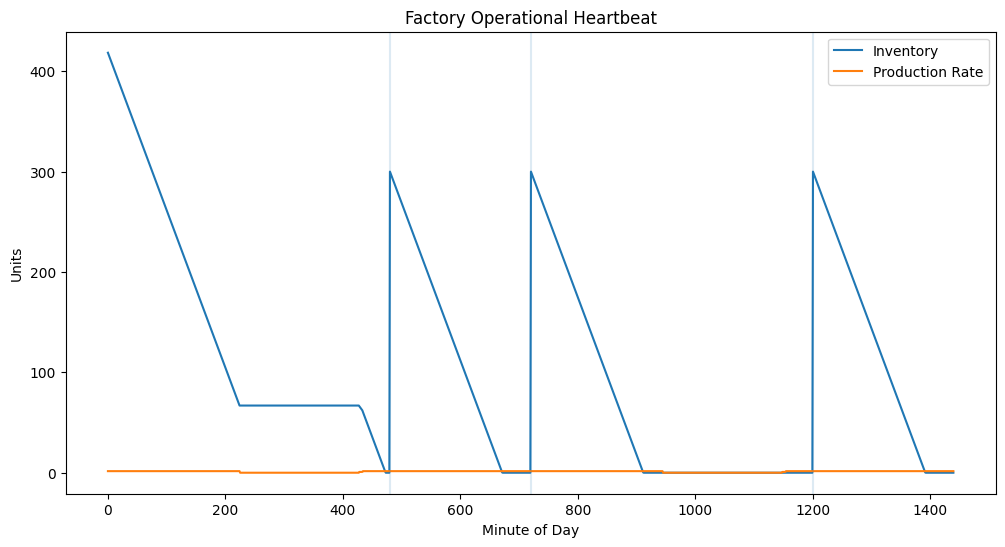

In [196]:
# ==========================
# Plant heartbeat visualization
# ==========================

truck_times = []

inventory = starting_inventory
inventory_trace = []
production_trace = []

minutes = []

for minute in range(1440):

    minute_of_day = minute

    apollo_running = (
        7*60+8 <= minute_of_day < shift_end
        or 19*60+8 <= minute_of_day < 24*60
        or 0 <= minute_of_day < 3*60+45
    )

    discovery_running = (
        7*60+14 <= minute_of_day < shift_end
        or 19*60+14 <= minute_of_day < 24*60
        or 0 <= minute_of_day < 3*60+45
    )

    apollo_prod = apollo_rate if apollo_running else 0
    discovery_prod = discovery_rate if discovery_running else 0

    total_prod = apollo_prod + discovery_prod

    if inventory >= total_prod:
        inventory -= total_prod
    else:
        inventory = 0

    if minute > 0 and minute % truck_interval == 0 and apollo_running:
        inventory += truck_parts
        truck_times.append(minute)

    minutes.append(minute)
    inventory_trace.append(inventory)
    production_trace.append(total_prod)

plt.figure(figsize=(12,6))

plt.plot(minutes, inventory_trace, label="Inventory")
plt.plot(minutes, production_trace, label="Production Rate")

for t in truck_times:
    plt.axvline(t, alpha=0.15)

plt.xlabel("Minute of Day")
plt.ylabel("Units")
plt.title("Factory Operational Heartbeat")

plt.legend()

plt.show()

In [197]:
import pandas as pd

results = pd.DataFrame({
    "Annual_Loss": annual_losses
})

results.to_csv("weather_supply_chain_simulation.csv", index=False)

print("CSV file saved.")

CSV file saved.


In [198]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("supply_chain_simulation_report.pdf") as pdf:

    # Annual loss distribution
    plt.figure()
    plt.hist(annual_losses, bins=40)
    plt.title("Annual Weather Disruption Distribution")
    plt.xlabel("Vehicles Lost")
    plt.ylabel("Frequency")
    pdf.savefig()
    plt.close()

    # Survival curve
    plt.figure()
    plt.plot(buffers, survival_times, marker='o')
    plt.title("Supply Chain Survival Curve")
    plt.xlabel("Inventory Buffer")
    plt.ylabel("Hours Survived")
    pdf.savefig()
    plt.close()

    # Heatmap
    plt.figure()
    plt.imshow(heatmap, aspect='auto', origin='lower')
    plt.colorbar()
    plt.title("Supply Chain Resilience Heatmap")
    pdf.savefig()
    plt.close()

print("PDF report generated.")

PDF report generated.
